# Polysubstance treatment completion post-review

Notebook version of `prop_grantt_25_postrev.qmd` up to the loading/setup section, plus the three reviewer-response analyses requested here:

1. Supplementary table of patients by calendar year and single vs multiple observed admissions.
2. Supplementary table comparing 1-admission patients vs multiple-admission patients.
3. Sensitivity GEE model comparing primary AUD vs non-AUD while adjusting for PSUD.

The notebook is intentionally lighter than the Quarto HTML document: HTML/CSS/JS presentation blocks are omitted, and the analysis starts from the saved `.Rdata` state already produced by the Quarto pipeline.


## Setup and data loading

This cell mirrors the Quarto path logic: it first climbs to the project root, then resolves the external `SISTRAT 2023` data folder.

If Positron asks for a kernel/interpreter, select the local R 4.4.1 interpreter. Positron bundles Jupyter kernel support for R once the interpreter is configured, so this notebook does not install `IRkernel` by default.


In [1]:
#| label: setup
#| results: "hold"

rm(list = ls())
gc()

time_before_dedup2 <- Sys.time()

find_project_root <- function(start = getwd(), markers = c("prop_grantt_25_postrev.qmd", "2023.Rproj")) {
  cur <- normalizePath(start, winslash = "/", mustWork = FALSE)
  repeat {
    if (any(file.exists(file.path(cur, markers)))) return(cur)
    parent <- dirname(cur)
    if (identical(parent, cur)) return(normalizePath(start, winslash = "/", mustWork = FALSE))
    cur <- parent
  }
}

project_root <- find_project_root()
setwd(project_root)
message("Project root: ", getwd())

find_python_rel <- function(start = getwd(), rel = file.path(".mamba_root", "envs", "py311", "python.exe")) {
  cur <- normalizePath(start, winslash = "/", mustWork = FALSE)
  repeat {
    cand <- normalizePath(file.path(cur, rel), winslash = "/", mustWork = FALSE)
    if (file.exists(cand)) return(cand)
    parent <- dirname(cur)
    if (identical(parent, cur)) return(NA_character_)
    cur <- parent
  }
}

if (requireNamespace("reticulate", quietly = TRUE)) {
  py <- find_python_rel()
  if (!is.na(py)) {
    Sys.unsetenv(c("RETICULATE_CONDAENV", "RETICULATE_PYTHON_FALLBACK"))
    Sys.setenv(RETICULATE_PYTHON = py)
    reticulate::use_python(py, required = TRUE)
    print(reticulate::py_config())
  } else {
    message("No local .mamba_root/envs/py311/python.exe found; continuing without binding reticulate.")
  }
}

resolve_wdpath <- function() {
  wd <- normalizePath(getwd(), winslash = "/", mustWork = FALSE)
  if (grepl("SISTRAT 2023", wd)) {
    paste0(gsub("/cons", "", gsub("cons", "", paste0(wd, "/cons"))))
  } else {
    paste0(gsub("/SISTRAT 2022 \\(github\\)/_proposal_grant/2023", "", wd), "/SISTRAT 2023/")
  }
}

wdpath <- resolve_wdpath()
rdata_file <- file.path(wdpath, "data", "20241015_out", "psu", "psu_ndp_2025_10_02.Rdata")
stopifnot(file.exists(rdata_file))
load(rdata_file)

out_dir <- file.path(getwd(), "output", "jupyter-notebook")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

message("Loaded: ", rdata_file)


Project root: G:/My Drive/Alvacast/SISTRAT 2022 (github)/_proposal_grant/2023
No local .mamba_root/envs/py311/python.exe found; continuing without binding reticulate.
Loaded: G:/My Drive/Alvacast/SISTRAT 2023//data/20241015_out/psu/psu_ndp_2025_10_02.Rdata


## Packages and helpers

The original Quarto installs packages inside the document. For the notebook, package installation is kept explicit and reproducible; missing packages are installed from the Chilean CRAN mirror used in the Quarto.


In [2]:
#| label: setup-packages
#| results: "hold"
local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos = r)
})

if (requireNamespace("renv", quietly = TRUE)) {
  renv::settings$use.cache(FALSE)
  renv::settings$snapshot.type("implicit")
}

required_packages <- c(
  "dplyr", "tidyr", "tibble", "tableone", "geepack", "broom",
  "knitr", "purrr", "magrittr",
  # added for the corrected sensitivity chunks ported from the Quarto:
  "sandwich", "lmtest", "mice", "IrregLong", "survival",
  "data.table", "tidytable", "lubridate", "stringr",
  "ggplot2", "cowplot", "scales"
)

missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]
if (length(missing_packages) > 0) install.packages(missing_packages)

suppressPackageStartupMessages(
  invisible(lapply(required_packages, library, character.only = TRUE))
)

`%>%` <- magrittr::`%>%`

if (Sys.info()[["sysname"]] == "Windows" && getRversion() != "4.4.1") {
  warning("Original Quarto expects R 4.4.1; current R is ", getRversion())
}

as.data.frame.TableOne <- function(x, ...) {
  capture.output(print(x, showAllLevels = TRUE, varLabels = TRUE, ...) -> x)
  y <- as.data.frame(x)
  y$characteristic <- dplyr::na_if(rownames(x), "")
  y <- y |>
    tidyr::fill(characteristic, .direction = "down") |>
    dplyr::select(characteristic, everything())
  rownames(y) <- NULL
  y
}

clean_weights <- function(w) {
  w[!is.finite(w) | is.na(w) | w <= 0] <- 1
  w / mean(w, na.rm = TRUE)
}


Warning messages:
1: package ‘dplyr’ was built under R version 4.4.3 
2: package ‘tibble’ was built under R version 4.4.3 
3: package ‘broom’ was built under R version 4.4.3 
4: package ‘knitr’ was built under R version 4.4.3 
5: package ‘IrregLong’ was built under R version 4.4.3 
6: package ‘data.table’ was built under R version 4.4.3 
7: package ‘stringr’ was built under R version 4.4.3 
8: package ‘ggplot2’ was built under R version 4.4.3 
9: package ‘cowplot’ was built under R version 4.4.3 
10: package ‘scales’ was built under R version 4.4.3 


## Loaded object audit

The supplementary tables use `SISTRAT_clean_drop_patient` so their patient counts match the post-exclusion universe. The sensitivity model uses `dat_with_weights_stab_cons`, which already contains the recurrent-care analytic dataset and stabilized IIW weights.


In [3]:
required_objects <- c("SISTRAT_clean_drop_patient", "dat_with_weights_stab_cons")
missing_objects <- setdiff(required_objects, ls())
if (length(missing_objects) > 0) stop("Missing objects: ", paste(missing_objects, collapse = ", "))

object_audit <- tibble::tibble(
  object = required_objects,
  rows = vapply(required_objects, function(nm) nrow(get(nm)), integer(1)),
  columns = vapply(required_objects, function(nm) ncol(get(nm)), integer(1)),
  patients = vapply(required_objects, function(nm) dplyr::n_distinct(get(nm)$hash_key), integer(1))
)

knitr::kable(object_audit, format = "pipe")




|object                     |   rows| columns| patients|
|:--------------------------|------:|-------:|--------:|
|SISTRAT_clean_drop_patient | 159106|     121|   118594|
|dat_with_weights_stab_cons |  67957|     152|    27445|

## Supplementary Table: Patients by first observed admission year

Rows are classified by first observed admission year from 2010 onward. Single vs multiple admission status is determined over the observed file. Because later cohorts have less follow-up time to accrue a subsequent admission, the rising single-admission proportion in recent years is vulnerable to right-censoring and should not be interpreted as a true secular shift in recurrent-care propensity.


In [4]:
#| label: patients-by-first-admission-year
#| results: "hold"

#cat("After discarding Any treatment w/ death or ongoing tr")
#length(unique(SISTRAT_clean_drop_patient$hash_key))
#[1] 118594

# --- Cohort preparation -------------------------------------------------------
# Cast the cleaned patient-level data to a plain data.frame for safer base/dplyr
# interoperability, and ensure the admission date is a proper Date object.
cohort_all <- as.data.frame(SISTRAT_clean_drop_patient)
cohort_all$adm_date_rec2 <- as.Date(cohort_all$adm_date_rec2)

# --- Identify each patient's first observed admission -------------------------
# Sort by patient identifier, numeric admission date, and calendar admission date
# so the earliest record per patient appears first. Within each patient, count
# the total number of observed admissions, keep only the first row, and then
# classify the patient into either a single-admission or multiple-admission group.
# Also extract the calendar year of that first observed admission.
person_first <- cohort_all |>
  dplyr::arrange(hash_key, adm_date_num_rec2, adm_date_rec2) |>
  dplyr::group_by(hash_key) |>
  dplyr::mutate(n_admissions_observed = dplyr::n()) |>
  dplyr::slice(1) |>
  dplyr::ungroup() |>
  dplyr::mutate(
    admission_group = dplyr::if_else(n_admissions_observed == 1L, "1 admission", "Multiple admissions"),
    first_admission_year = as.integer(format(adm_date_rec2, "%Y"))
  )

# --- Build the supplementary table by first admission year --------------------
# Any first admission recorded before 2010 is treated as a 2010 entry because
# those dates reflect administrative carry-over rather than true pre-2010
# treatment starts. Patients are then counted by calendar year and admission
# group, yearly totals and percentages are computed, and the result is reshaped
# into a wide presentation table.
supp_table_admission_year <- person_first |>
  dplyr::filter(!is.na(first_admission_year)) |>#, first_admission_year >= 2010
  dplyr::mutate(
    first_admission_year = dplyr::if_else(first_admission_year < 2010, 2010L, first_admission_year)
  ) |>
  dplyr::filter(!is.na(first_admission_year)) |>
  dplyr::count(first_admission_year, admission_group, name = "n") |>
  dplyr::group_by(first_admission_year) |>
  dplyr::mutate(total_patients = sum(n), proportion = n / total_patients) |>
  dplyr::ungroup() |>
  dplyr::mutate(
    n = as.integer(n),
    proportion_percent = round(100 * proportion, 1)
  ) |>
  dplyr::select(first_admission_year, admission_group, n, total_patients, proportion_percent) |>
  tidyr::pivot_wider(
    names_from = admission_group,
    values_from = c(n, proportion_percent),
    values_fill = 0,
    names_glue = "{admission_group}_{.value}"
  ) |>
  dplyr::transmute(
    `First observed admission year` = first_admission_year,
    `Total patients` = total_patients,
    `1 admission, n` = `1 admission_n`,
    `1 admission, %` = `1 admission_proportion_percent`,
    `Multiple admissions, n` = `Multiple admissions_n`,
    `Multiple admissions, %` = `Multiple admissions_proportion_percent`
  ) |>
  dplyr::arrange(`First observed admission year`)

# Optional CSV export (currently commented out):
# write.csv(
#   supp_table_admission_year,
#   file.path(out_dir, "supp_table_patients_by_first_admission_year.csv"),
#   row.names = FALSE,
#   fileEncoding = "UTF-8"
# )

# --- Render the table ---------------------------------------------------------
# Display the supplementary table as a Markdown pipe table using knitr::kable.
print(knitr::kable(
  supp_table_admission_year,
  format = "pipe",
  caption = "Supplementary Table. Patients by first observed admission year and observed admission multiplicity."
))

print(paste0("total patients:", supp_table_admission_year$`Total patients` |> sum()))



Table: Supplementary Table. Patients by first observed admission year and observed admission multiplicity.

| First observed admission year| Total patients| 1 admission, n| 1 admission, %| Multiple admissions, n| Multiple admissions, %|
|-----------------------------:|--------------:|--------------:|--------------:|----------------------:|----------------------:|
|                          2010|           9505|           5954|           62.6|                   3551|                   37.4|
|                          2011|           6414|           4036|           62.9|                   2378|                   37.1|
|                          2012|           6519|           4187|           64.2|                   2332|                   35.8|
|                          2013|           9201|           6371|           69.2|                   2830|                   30.8|
|                          2014|           8891|           6315|           71.0|                   2576|            

In [5]:
supp_table_admission_year <- person_first |>
  dplyr::mutate(
    first_admission_year = dplyr::if_else(first_admission_year < 2010, 2010L, first_admission_year)
  ) |>
  dplyr::filter(!is.na(first_admission_year)) |>
  dplyr::count(first_admission_year, admission_group, name = "n") |>
  dplyr::group_by(first_admission_year) |>
  dplyr::mutate(total_patients = sum(n), proportion = n / total_patients) |>
  dplyr::ungroup() |>
  dplyr::mutate(
    n = as.integer(n),
    proportion_percent = round(100 * proportion, 1)
  ) |>
  dplyr::select(first_admission_year, admission_group, n, total_patients, proportion_percent) |>
  tidyr::pivot_wider(
    names_from = admission_group,
    values_from = c(n, proportion_percent),
    values_fill = 0,
    names_glue = "{admission_group}_{.value}"
  ) |>
  dplyr::transmute(
    `First observed admission year` = first_admission_year,
    `Total patients` = total_patients,
    `1 admission, n` = `1 admission_n`,
    `1 admission, %` = `1 admission_proportion_percent`,
    `Multiple admissions, n` = `Multiple admissions_n`,
    `Multiple admissions, %` = `Multiple admissions_proportion_percent`
  ) |>
  dplyr::arrange(`First observed admission year`)

### Sensitivity, first_admission_year <= 2021

In [6]:
#| label: sensitivity-48m-admin-censoring
#| results: "hold"

# Primary stratified PSUD model (modified-Poisson GEE) + 48-month administrative-
# censoring sensitivity. Administrative censoring date: 2025-05-28; the exact 48-month
# opportunity cutoff is a first admission on or before 2021-05-28. Run for both
# w0_tr (lag-0) and w1_tr (lag-1) inverse-intensity weights.
#
# AUDIT NOTE (2026-06-04): the outcome formula adjusts for primary substance with all
# five categories distinguished, using ALCOHOL as the reference category (include
# susprindum_coc + susprindum_pbc + susprindum_mar + susprindum_oth; omit susprindum_oh).
# The Quarto source omitted both susprindum_oh and susprindum_oth, which incorrectly
# collapsed alcohol + other into the reference. The reference choice is a reparameterization
# and does not change the PSUD RR or predictions (verified identical to ~1e-15).

suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(geepack); library(broom); library(purrr); library(knitr)
})

if (!exists("dat_with_weights_stab_cons")) {
  wd <- normalizePath(getwd(), winslash = "/", mustWork = FALSE)
  wdpath <- if (grepl("SISTRAT 2023", wd)) {
    paste0(gsub("/cons", "", gsub("cons", "", paste0(wd, "/cons"))))
  } else {
    paste0(gsub("/SISTRAT 2022 \\(github\\)/_proposal_grant/2023", "", wd), "/SISTRAT 2023/")
  }
  rdata_file <- file.path(wdpath, "data", "20241015_out", "psu", "psu_ndp_2025_10_02.Rdata")
  stopifnot(file.exists(rdata_file)); load(rdata_file)
}

if (!exists("clean_weights")) {
  clean_weights <- function(w) { w[!is.finite(w) | is.na(w) | w <= 0] <- 1; w / mean(w, na.rm = TRUE) }
}
if (!exists("weight_label")) {
  weight_label <- function(weight_col) {
    if (is.null(weight_col)) "unweighted" else as.character(weight_col)
  }
}

# Outcome formula: alcohol-reference parameterization.
OUTCOME_SUBSTANCE_TERMS <- c("susprindum_coc", "susprindum_pbc", "susprindum_mar", "susprindum_oth")

base_terms <- c(
  "polysubstance_strict",
  "biopsych_comp_severe",
  "age_c10",
  "year_c",
  "susinidum_oh",
  "susinidum_coc",
  "susinidum_pbc",
  "susinidum_mar",
  "dg_psiq_cie_10_instudy",
  "dg_psiq_cie_10_dg",
  "prim_sub_daily",
  "occ24_inactive",
  "occ24_unemployed",
  OUTCOME_SUBSTANCE_TERMS
)

reduce_formula <- function(ff, mf) {
  X <- stats::model.matrix(ff, mf)
  assign_vec <- attr(X, "assign")
  term_labels <- attr(stats::terms(ff), "term.labels")

  const <- vapply(as.data.frame(X), function(v) length(unique(v)) == 1L, logical(1))
  const[colnames(X) == "(Intercept)"] <- FALSE

  if (any(const)) {
    X <- X[, !const, drop = FALSE]
    assign_vec <- assign_vec[!const]
  }

  qrX <- qr(X)
  keep_cols <- sort(qrX$pivot[seq_len(qrX$rank)])
  kept_term_idx <- sort(unique(assign_vec[keep_cols][assign_vec[keep_cols] > 0]))
  kept_terms <- term_labels[kept_term_idx]

  if (!"polysubstance_strict" %in% kept_terms) {
    stop("polysubstance_strict was dropped from the model; check this stratum.")
  }

  stats::reformulate(kept_terms, response = "tr_noncompletion")
}

fit_psud_gee <- function(df, sample_label, plan_label, weight_col = NULL, include_plan = FALSE) {
  df <- df |>
    dplyr::mutate(id = as.character(id))

  candidate_terms <- base_terms
  if (include_plan) candidate_terms <- c("plan_type_mod", candidate_terms)

  candidate_terms <- intersect(candidate_terms, names(df))
  ff <- stats::reformulate(candidate_terms, response = "tr_noncompletion")

  mf0 <- stats::model.frame(ff, data = df, na.action = stats::na.pass)

  keep <- stats::complete.cases(mf0) & !is.na(df$id)

  if (!is.null(weight_col)) {
    if (!weight_col %in% names(df)) stop("Missing weight column: ", weight_col)

    keep <- keep &
      is.finite(df[[weight_col]]) &
      !is.na(df[[weight_col]]) &
      df[[weight_col]] > 0
  }

  mf <- mf0[keep, , drop = FALSE]

  if (nrow(mf) == 0L || length(unique(stats::model.response(mf))) < 2L) {
    return(NULL)
  }

  ff_reduced <- reduce_formula(ff, mf)

  fit_args <- list(
    formula = ff_reduced,
    id = df$id[keep],
    data = mf,
    family = poisson(link = "log"),
    corstr = "independence",
    scale.fix = TRUE,
    na.action = stats::na.exclude
  )

  if (!is.null(weight_col)) {
    fit_args$weights <- clean_weights(df[[weight_col]][keep])
  }

  fit <- do.call(geepack::geeglm, fit_args)

  broom::tidy(fit, exponentiate = TRUE, conf.int = TRUE) |>
    dplyr::filter(term == "polysubstance_strict") |>
    dplyr::transmute(
      sample = sample_label,
      weight = weight_label(weight_col),
      plan_type_mod = plan_label,
      n_rows = nrow(mf),
      n_patients = dplyr::n_distinct(df$id[keep]),
      RR = estimate,
      conf_low = conf.low,
      conf_high = conf.high,
      p_value = p.value,
      `RR (95% CI)` = sprintf("%.2f (%.2f, %.2f)", estimate, conf.low, conf.high)
    )
}

fit_psud_overall <- function(dat, sample_label, weight_col = NULL) {
  fit_psud_gee(
    df = dat,
    sample_label = sample_label,
    plan_label = "Overall adjusted for setting",
    weight_col = weight_col,
    include_plan = TRUE
  )
}

fit_psud_by_plan <- function(dat, sample_label, weight_col = NULL) {
  split(dat, dat$plan_type_mod) |>
    purrr::imap_dfr(function(df, pt) {
      fit_psud_gee(
        df = df,
        sample_label = sample_label,
        plan_label = as.character(pt),
        weight_col = weight_col,
        include_plan = FALSE
      )
    })
}

dat <- as.data.frame(dat_with_weights_stab_cons)

if (!"susprindum_oth" %in% names(dat) && "primary_sub_mod" %in% names(dat)) {
  dat$susprindum_oth <- as.integer(dat$primary_sub_mod == "others")
}

dat$adm_date_rec2 <- as.Date(dat$adm_date_rec2)
dat$id <- as.character(dat$id)

first_dates <- dat |>
  dplyr::group_by(hash_key) |>
  dplyr::summarise(
    first_admission_date = min(adm_date_rec2, na.rm = TRUE),
    .groups = "drop"
  )

dat <- dat |>
  dplyr::left_join(first_dates, by = "hash_key") |>
  dplyr::mutate(
    censor_date = as.Date("2025-05-28"),
    followup_opportunity_months =
      as.numeric(difftime(censor_date, first_admission_date, units = "days")) / 30.4375,
    eligible_48m = first_admission_date <= as.Date("2021-05-28")
  )

dat_48m <- dat |>
  dplyr::filter(eligible_48m)

sample_counts <- dplyr::bind_rows(
  dat |>
    dplyr::summarise(
      sample = "full recurrent",
      n_rows = dplyr::n(),
      n_patients = dplyr::n_distinct(hash_key),
      min_followup_opportunity_months = min(followup_opportunity_months, na.rm = TRUE),
      median_followup_opportunity_months = median(followup_opportunity_months, na.rm = TRUE),
      .groups = "drop"
    ),
  dat_48m |>
    dplyr::summarise(
      sample = "first admission date <= 2021-05-28 (>=48m)",
      n_rows = dplyr::n(),
      n_patients = dplyr::n_distinct(hash_key),
      min_followup_opportunity_months = min(followup_opportunity_months, na.rm = TRUE),
      median_followup_opportunity_months = median(followup_opportunity_months, na.rm = TRUE),
      .groups = "drop"
    )
)

weight_specs <- list("w1_tr", "w0_tr", NULL)

run_psud_set <- function(dat_sample, sample_label) {
  purrr::map_dfr(weight_specs, function(w) {
    dplyr::bind_rows(
      fit_psud_overall(dat_sample, sample_label, w),
      fit_psud_by_plan(dat_sample, sample_label, w)
    )
  })
}

psud_primary_and_48m_results <- dplyr::bind_rows(
  run_psud_set(dat, "full recurrent"),
  run_psud_set(dat_48m, "first admission date <= 2021-05-28 (>=48m)")
)

cat("Sample counts:\n")
print(sample_counts)

cat("\nPrimary PSUD model and exact 48-month sensitivity:\n")
print(knitr::kable(
  psud_primary_and_48m_results |>
    dplyr::select(sample, weight, plan_type_mod, n_patients, `RR (95% CI)`, p_value),
  format = "markdown",
  digits = 4,
  caption = "Primary stratified PSUD modified-Poisson GEE and exact 48-month administrative-censoring sensitivity."
))

Sample counts:
                                      sample n_rows n_patients min_followup_opportunity_months median_followup_opportunity_months
1                             full recurrent  67957      27445                        7.425051                           129.4784
2 first admission date <= 2021-05-28 (>=48m)  64004      25576                       48.000000                           132.7639

Primary PSUD model and exact 48-month sensitivity:


Table: Primary stratified PSUD modified-Poisson GEE and exact 48-month administrative-censoring sensitivity.

|sample                                     |weight     |plan_type_mod                | n_patients|RR (95% CI)       | p_value|
|:------------------------------------------|:----------|:----------------------------|----------:|:-----------------|-------:|
|full recurrent                             |w1_tr      |Overall adjusted for setting |      27445|1.05 (1.03, 1.06) |  0.0000|
|full recurrent                             |w1

## Supplementary Table: 1 admission vs multiple admissions

This patient-level comparison uses the first observed admission row for each patient and preserves the post-exclusion universe used in the reviewer response: 91,149 patients with one observed admission and 27,445 patients with multiple observed admissions.


In [8]:
#| label: table-one-admission-characteristics-one-vs-multiple
#| results: "hold"

# helper missing from this notebook (no-op if you later restore the real one)
if (!exists("format_cells")) {
  format_cells <- function(df, rows, cols,
                           value = c("italics", "bold", "strikethrough")) {
    map    <- setNames(c("*", "**", "~~"),
                       c("italics", "bold", "strikethrough"))
    markup <- map[value]
    for (r in rows) for (c in cols) {
      df[[c]]  <- as.character(df[[c]])
      df[r, c] <- ifelse(nchar(df[r, c]) == 0, "",
                         paste0(markup, gsub(" ", "", df[r, c]), markup))
    }
    df
  }
}

# Work on a copy so person_first is not polluted with indicator columns.
pf <- person_first

# ---- per-level binary indicators (article Table 1 style; level strings
#      verified against the dummy-builders elsewhere in this notebook) -------
pf$sex_women    <- as.integer(pf$sex_rec == "mujer")                      # positive = women

pf$set_gp_basic <- as.integer(pf$plan_type_mod == "GP basic ambulatory")
pf$set_gp_int   <- as.integer(pf$plan_type_mod == "GP intensive ambulatory")
pf$set_gp_res   <- as.integer(pf$plan_type_mod == "GP residential")
pf$set_wo_int   <- as.integer(pf$plan_type_mod == "WO intensive ambulatory")
pf$set_wo_res   <- as.integer(pf$plan_type_mod == "WO residential")

pf$ini_coc <- as.integer(pf$sus_ini_mod_mvv == "cocaine powder")         # hydrochloride
pf$ini_pbc <- as.integer(pf$sus_ini_mod_mvv == "cocaine paste")          # base paste
pf$ini_mar <- as.integer(pf$sus_ini_mod_mvv == "marijuana")
pf$ini_oh  <- as.integer(pf$sus_ini_mod_mvv == "alcohol")
pf$ini_oth <- as.integer(pf$sus_ini_mod_mvv == "others")

pf$adm_pbc <- as.integer(pf$primary_sub_mod == "cocaine paste")
pf$adm_coc <- as.integer(pf$primary_sub_mod == "cocaine powder")
pf$adm_mar <- as.integer(pf$primary_sub_mod == "marijuana")
pf$adm_oh  <- as.integer(pf$primary_sub_mod == "alcohol")
pf$adm_oth <- as.integer(pf$primary_sub_mod == "others")

pf$occ_emp   <- as.integer(pf$occupation_condition_corr24 == "employed")
pf$occ_inact <- as.integer(pf$occupation_condition_corr24 == "inactive")
pf$occ_unemp <- as.integer(pf$occupation_condition_corr24 == "unemployed")
pf$days_to_dropout <- ifelse(pf$tr_noncompletion == 1, exp(pf$treat_log_days), NA_real_)
# Create admission year with month as decimal fraction
pf$adm_date <- as.Date(pf$adm_date_num_rec2, origin = "1970-01-01")
pf$adm_year_decimal <- lubridate::year(pf$adm_date) + 
                       (lubridate::month(pf$adm_date) - 1) / 12 + 
                       (lubridate::day(pf$adm_date) - 1) / 365.25
# ---- safety net: flag any indicator that came out all-zero (= level typo) --
.ind <- c("sex_women","set_gp_basic","set_gp_int","set_gp_res","set_wo_int",
          "set_wo_res","ini_coc","ini_pbc","ini_mar","ini_oh","ini_oth",
          "adm_pbc","adm_coc","adm_mar","adm_oh","adm_oth",
          "occ_emp","occ_inact","occ_unemp")
.bad <- .ind[vapply(.ind, function(v) sum(pf[[v]], na.rm = TRUE) == 0, logical(1))]
if (length(.bad)) warning("All-zero indicator(s) — check level strings: ",
                          paste(.bad, collapse = ", "))

# ---- variable order EXACTLY as requested (= row order in the output) -------
vars_ordered <- c(
  "sex_women",
  "set_gp_basic", "set_gp_int", "set_gp_res", "set_wo_int", "set_wo_res",
  "polysubstance_strict", "tr_noncompletion", "biopsych_comp_severe", "treat_lt_90",
  "treat_log_days", "adm_age_rec3", "year_decimal",
  "ini_coc", "ini_pbc", "ini_mar", "ini_oh", "ini_oth",
  "dg_psiq_cie_10_instudy", "dg_psiq_cie_10_dg", "prim_sub_daily",
  "occ_emp", "occ_inact", "occ_unemp",
  "adm_pbc", "adm_coc", "adm_mar", "adm_oh", "adm_oth",
  #2026-06-04: added days_to_dropout and adm_year_decimal to the end of the list, after verifying their presence in pf
  "days_to_dropout", "adm_year_decimal"
)

nonnormal_vars <- intersect(
  c("treat_log_days", "days_to_dropout", "adm_age_rec3", "adm_year_decimal", "year_decimal"),
  vars_ordered
)
factor_vars <- setdiff(vars_ordered, nonnormal_vars)

cat("pf rows:", nrow(pf), "\n")
cat("vars_ordered length:", length(vars_ordered), "\n")
cat("missing vars:", paste(setdiff(vars_ordered, names(pf)), collapse = ", "), "\n")
cat("nonnormal_vars:", paste(nonnormal_vars, collapse = ", "), "\n")
cat("days_to_dropout finite:", sum(is.finite(pf$days_to_dropout)), "\n")
cat("adm_year_decimal finite:", sum(is.finite(pf$adm_year_decimal)), "\n")
print(summary(pf[c("days_to_dropout", "adm_year_decimal")]))


# ---- labels (tableone appends " (%)" / " (median [IQR])") ------------------
labels <- c(
  sex_women              = "Sex",
  set_gp_basic           = "Treatment setting at first observed admission: General-population basic ambulatory",
  set_gp_int             = "Treatment setting at first observed admission: General-population intensive ambulatory",
  set_gp_res             = "Treatment setting at first observed admission: General-population residential",
  set_wo_int             = "Treatment setting at first observed admission: Women-only intensive ambulatory",
  set_wo_res             = "Treatment setting at first observed admission: Women-only residential",
  polysubstance_strict   = "PSUD at first observed admission",
  tr_noncompletion       = "Non-completion status of treatment (Dropout/Expelled due to misconduct)",
  biopsych_comp_severe   = "Severe biopsychosocial compromise",
  treat_lt_90            = "Treatment duration (binary) (<90 days)",
  treat_log_days         = "Treatment duration, log days",
  adm_age_rec3           = "Age at admission to treatment",
  year_decimal           = "Birth year",
  ini_coc                = "Primary substance (initial diagnosis): cocaine hydrochloride",
  ini_pbc                = "Primary substance (initial diagnosis): cocaine base paste",
  ini_mar                = "Primary substance (initial diagnosis): marijuana",
  ini_oh                 = "Primary substance (initial diagnosis): alcohol",
  ini_oth                = "Primary substance (initial diagnosis): other",
  dg_psiq_cie_10_instudy = "Psychiatric comorbidity (ICD-10): In study",
  dg_psiq_cie_10_dg      = "Psychiatric comorbidity (ICD-10): Diagnosis",
  prim_sub_daily         = "Daily frequency of primary substance used at admission",
  occ_emp                = "Occupational Status: Employed",
  occ_inact              = "Occupational Status: Inactive",
  occ_unemp              = "Occupational Status: Unemployed",
  adm_pbc                = "Primary substance at admission to treatment: cocaine base paste",
  adm_coc                = "Primary substance at admission to treatment: cocaine hydrochloride",
  adm_mar                = "Primary substance at admission to treatment: marijuana",
  adm_oh                 = "Primary substance at admission to treatment: alcohol",
  adm_oth                = "Primary substance at admission to treatment: other",
  days_to_dropout        = "Days to non-completion among non-completers",
  adm_year_decimal       = "Admission year (decimal)"
)
for (nm in intersect(names(labels), names(pf))) {
  attr(pf[[nm]], "label") <- unname(labels[[nm]])
}

# ---- TableOne: every SMD here is a per-level binary SMD --------------------

cat("\nRunning CreateTableOne...\n")
t1 <- Sys.time()
supp_table_one <- tableone::CreateTableOne(
  vars = vars_ordered,
  strata = "admission_group",
  data = pf,
  factorVars = factor_vars,
  addOverall = TRUE,
  includeNA = FALSE,
  smd = TRUE,
  test = TRUE
)
cat("CreateTableOne seconds:", round(as.numeric(difftime(Sys.time(), t1, units = "secs")), 1), "\n")

df_supp <- as.data.frame.TableOne(
  supp_table_one, nonnormal = nonnormal_vars, smd = TRUE
)

# strata columns detected from the data ("1 admission", "Multiple admissions")
strata_cols <- intersect(
  sort(unique(as.character(pf$admission_group))), names(df_supp)
)

cat("\nRows matching days/dropout/admission year:\n")
print(df_supp[grepl("Days to|Admission year|days_to|adm_year", df_supp$characteristic), ])

cat("\nLast 8 df_supp rows:\n")
print(utils::tail(df_supp, 8))

cat("\nUnique characteristics count:", length(unique(df_supp$characteristic)), "\n")
cat("Contains days row:", any(grepl("Days to|days_to", df_supp$characteristic)), "\n")
cat("Contains admission-year row:", any(grepl("Admission year|adm_year", df_supp$characteristic)), "\n")

# ---- format like "Descriptives, again"; row order is already vars_ordered --
supp_table_admission_characteristics <- df_supp |>
  dplyr::mutate(dplyr::across(dplyr::everything(), as.character)) |>
  dplyr::mutate(dplyr::across(dplyr::all_of(c(strata_cols, "Overall")),
                              ~ gsub("\\(\\s+", "(", .x))) |>
  dplyr::mutate(dplyr::across(dplyr::everything(),
                              ~ ifelse(nchar(.x) < 1, NA, .x))) |>
  dplyr::select(characteristic, level,
                dplyr::all_of(strata_cols), Overall, SMD) |>
  dplyr::group_by(characteristic) |>
  tidyr::fill(SMD, .direction = "updown") |>
  dplyr::ungroup() |>
  dplyr::filter(!level %in% c("0", "FALSE") | is.na(level)) |>  # keep NA for continuous vars
  tibble::as_tibble()

# write.csv(
#   supp_table_admission_characteristics,
#   file.path(out_dir, "supp_table_1_vs_multiple_admissions_characteristics.csv"),
#   row.names = FALSE, fileEncoding = "UTF-8"
# )

supp_table_admission_characteristics |>
  (\(df) format_cells(df, 1, 1:length(names(df)), "bold"))() |>
  knitr::kable(
    "markdown",
    caption = paste(
      "Supplementary Table. Characteristics at the first observed admission, by",
      "observed admission multiplicity (single vs. multiple). Standardized mean",
      "differences are computed level-by-level (each category as a binary indicator)."
    )
  ) |> print()

pf rows: 118594 
vars_ordered length: 31 
missing vars:  
nonnormal_vars: treat_log_days, days_to_dropout, adm_age_rec3, adm_year_decimal, year_decimal 
days_to_dropout finite: 84778 
adm_year_decimal finite: 118594 
 days_to_dropout  adm_year_decimal
 Min.   :   1.0   Min.   :2000    
 1st Qu.:  79.0   1st Qu.:2014    
 Median : 136.0   Median :2017    
 Mean   : 184.9   Mean   :2017    
 3rd Qu.: 232.0   3rd Qu.:2020    
 Max.   :1848.0   Max.   :2025    
 NA's   :33816                    

Running CreateTableOne...
CreateTableOne seconds: 2.2 

Rows matching days/dropout/admission year:
                                               characteristic level                    Overall                1 admission        Multiple admissions      p    test
57 Days to non-completion among non-completers (median [IQR])           136.00 [79.00, 232.00]     135.00 [79.00, 229.00]     139.00 [80.00, 237.00]  0.019 nonnorm
58                    Admission year (decimal) (median [IQR])       2016.91

~ 5 minutes

## Baseline treatment setting or not?

In [9]:

# rows are episodes, not patients?
nrow(dat_with_weights_stab_cons)     |>  print()             # expect ~67,957
n_distinct(dat_with_weights_stab_cons$hash_key) |>  print()  # expect ~27,445

# does setting vary WITHIN patients across episodes?
dat_with_weights_stab_cons |>
  summarise(n_settings = n_distinct(plan_type_mod), .by = hash_key) |>
  count(n_settings) |>  print()

# share of patients ever treated in >1 setting
dat_with_weights_stab_cons |>
  summarise(changed = n_distinct(plan_type_mod) > 1, .by = hash_key) |>
  summarise(patients = n(), changed_n = sum(changed),
            changed_pct = round(100*mean(changed), 1))|>  print()


[1] 67957
[1] 27445
# A tidytable: 1 × 2
  n_settings     n
       <int> <int>
1          1 27445
# A tidytable: 1 × 3
  patients changed_n changed_pct
     <int>     <int>       <dbl>
1    27445         0           0


In [11]:
#| label: baseline-treatment-setting-variability
#| results: "hold"

# find the per-admission setting column name
grep("plan|tipo_de_plan", names(SISTRAT_clean_drop_patient), value = TRUE, ignore.case = TRUE) |> print()

recur_ids <- unique(dat_with_weights_stab_cons$hash_key)   # the 27,445 recurrent patients

# how many were ever treated in >1 distinct setting across admissions?
SISTRAT_clean_drop_patient |>
  filter(hash_key %in% recur_ids) |>
  arrange(hash_key, adm_date_rec2) |>
  summarise(n_settings = n_distinct(plan_type_corr), n_adm = n(), .by = hash_key) |>
  summarise(patients         = n(),
            ever_changed_n   = sum(n_settings > 1),
            ever_changed_pct = round(100*mean(n_settings > 1), 1),
            median_settings  = median(n_settings)) |> print()

# transition matrix (consecutive admissions)
SISTRAT_clean_drop_patient |>
  filter(hash_key %in% recur_ids) |>
  arrange(hash_key, adm_date_rec2) |>
  mutate(next_plan = lead(plan_type_corr), .by = hash_key) |>
  filter(!is.na(next_plan)) |>
  count(plan_type_corr, next_plan) |>
  tidyr::pivot_wider(names_from = next_plan, values_from = n, values_fill = 0) |> print()

recur_ids <- unique(dat_with_weights_stab_cons$hash_key)

SISTRAT_clean_drop_patient |>
  filter(hash_key %in% recur_ids) |>
  summarise(n_settings = n_distinct(plan_type_corr), .by = hash_key) |>
  summarise(patients = n(),
            ever_changed_pct = round(100*mean(n_settings > 1), 1)) |> print()


[1] "plan_type"        "plan_type_series" "plan_type_corr"   "plan_type_mod"   
# A tidytable: 1 × 4
  patients ever_changed_n ever_changed_pct median_settings
     <int>          <int>            <dbl>           <int>
1    27445          15170             55.3               2
# A tibble: 5 × 6
  plan_type_corr `m-pai` `m-pr` `pg-pab` `pg-pai` `pg-pr`
  <chr>            <int>  <int>    <int>    <int>   <int>
1 m-pai             1286    670      287      502      49
2 m-pr               808   1454      407      915      47
3 pg-pab             391    407     5470     3645    1314
4 pg-pai             565    786     2422     9133    2854
5 pg-pr               65     95      956     2495    3489
# A tidytable: 1 × 2
  patients ever_changed_pct
     <int>            <dbl>
1    27445             55.3


#### Sankey

Using SISTRAT_clean_drop_patient already in memory.
# A tibble: 25 × 6
   first_setting  second_setting     n pct_total pct_of_first pct_of_second
   <chr>          <chr>          <int> <chr>     <chr>        <chr>        
 1 GP intensive   GP intensive    6484 23.6%     59.1%        56.3%        
 2 GP basic       GP basic        4289 15.6%     50.0%        60.3%        
 3 GP basic       GP intensive    2742 10.0%     32.0%        23.8%        
 4 GP residential GP residential  1941 7.1%      47.8%        40.5%        
 5 GP intensive   GP residential  1826 6.7%      16.6%        38.1%        
 6 GP intensive   GP basic        1799 6.6%      16.4%        25.3%        
 7 GP residential GP intensive    1426 5.2%      35.1%        12.4%        
 8 GP basic       GP residential   964 3.5%      11.2%        20.1%        
 9 WO intensive   WO intensive     868 3.2%      47.7%        43.3%        
10 WO residential WO residential   790 2.9%      39.2%        39.1%        
11 GP residential

Warning messages:
1: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.
2: In to_lodes_form(data = data, axes = axis_ind, discern = params$discern) :
  Some strata appear at multiple axes.


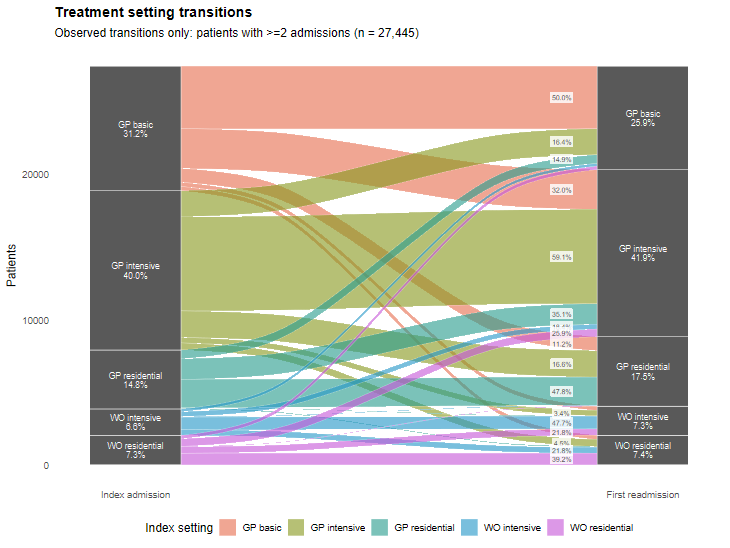

In [19]:
#| label: baseline-treatment-setting-variability-sankey
#| results: "hold"

# Sankey: observed Adm_1 -> Adm_2 transitions, no censorship

rdata_file <- "G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/psu/psu_ndp_2025_10_02.Rdata"
output_dir <- "_figs"

min_stratum_label_n <- 500
min_flow_label_n <- 300

needed <- c("dplyr", "tidyr", "ggplot2", "ggalluvial", "scales")
missing <- needed[!vapply(needed, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing)) stop("Install missing packages: ", paste(missing, collapse = ", "))

get_or_load <- function(object_name, rdata_file) {
  if (base::exists(object_name, envir = .GlobalEnv, inherits = TRUE)) {
    message("Using ", object_name, " already in memory.")
    return(base::get(object_name, envir = .GlobalEnv, inherits = TRUE))
  }

  message(object_name, " not found in memory. Loading: ", rdata_file)
  data_env <- new.env(parent = emptyenv())
  base::load(rdata_file, envir = data_env)

  if (!base::exists(object_name, envir = data_env, inherits = FALSE)) {
    stop(object_name, " was not found in ", rdata_file)
  }

  base::get(object_name, envir = data_env, inherits = FALSE)
}

df <- base::as.data.frame(
  get_or_load("SISTRAT_clean_drop_patient", rdata_file)
)

setting_col <- base::intersect(
  c("plan_type_corr", "tipo_de_plan_2", "plan_type", "plan_type_mod"),
  names(df)
)[1]

if (base::is.na(setting_col)) stop("No treatment-setting column found.")

recode_setting <- function(x) {
  x <- base::tolower(base::trimws(base::as.character(x)))
  x <- base::gsub("[ _]", "-", x)

  dplyr::case_when(
    x %in% c("pg-pab", "gp-basic", "gp-basic-ambulatory") ~ "GP basic",
    x %in% c("pg-pai", "gp-intensive", "gp-intensive-ambulatory") ~ "GP intensive",
    x %in% c("pg-pr", "gp-residential") ~ "GP residential",
    x %in% c("m-pai", "wo-intensive", "wo-intensive-ambulatory") ~ "WO intensive",
    x %in% c("m-pr", "wo-residential") ~ "WO residential",
    TRUE ~ NA_character_
  )
}

has_adm_date_num <- "adm_date_num_rec2" %in% names(df)

patient_seq <- df |>
  dplyr::mutate(
    hash_key_chr = base::as.character(.data$hash_key),
    adm_date_sort = base::as.Date(.data$adm_date_rec2),
    adm_date_num_sort = if (has_adm_date_num) {
      suppressWarnings(base::as.numeric(.data$adm_date_num_rec2))
    } else {
      suppressWarnings(base::as.numeric(.data$adm_date_sort))
    },
    setting = recode_setting(.data[[setting_col]])
  ) |>
  dplyr::filter(!base::is.na(.data$setting)) |>
  dplyr::arrange(.data$hash_key_chr, .data$adm_date_sort, .data$adm_date_num_sort) |>
  dplyr::group_by(.data$hash_key_chr) |>
  dplyr::mutate(adm_seq = dplyr::row_number()) |>
  dplyr::ungroup() |>
  dplyr::filter(.data$adm_seq <= 2L)

wide <- patient_seq |>
  dplyr::transmute(
    hash_key_chr = .data$hash_key_chr,
    adm = paste0("Adm_", .data$adm_seq),
    setting = .data$setting
  ) |>
  tidyr::pivot_wider(
    id_cols = "hash_key_chr",
    names_from = "adm",
    values_from = "setting"
  ) |>
  dplyr::filter(!base::is.na(.data$Adm_1), !base::is.na(.data$Adm_2))

if (nrow(wide) == 0L) stop("No observed Adm_1 -> Adm_2 transitions found.")

total_n <- nrow(wide)

counts <- wide |>
  dplyr::count(.data$Adm_1, .data$Adm_2, name = "n") |>
  dplyr::arrange(dplyr::desc(.data$n))

first_marginal <- counts |>
  dplyr::group_by(.data$Adm_1) |>
  dplyr::summarise(first_n = sum(.data$n), .groups = "drop") |>
  dplyr::mutate(first_prop = .data$first_n / total_n)

second_marginal <- counts |>
  dplyr::group_by(.data$Adm_2) |>
  dplyr::summarise(second_n = sum(.data$n), .groups = "drop") |>
  dplyr::mutate(second_prop = .data$second_n / total_n)

transition_table <- counts |>
  dplyr::left_join(first_marginal, by = "Adm_1") |>
  dplyr::left_join(second_marginal, by = "Adm_2") |>
  dplyr::mutate(
    transition_prop_total = .data$n / total_n,
    transition_prop_of_first_treatment = .data$n / .data$first_n,
    transition_prop_of_second_treatment = .data$n / .data$second_n
  )

print(
  transition_table |>
    dplyr::transmute(
      first_setting = .data$Adm_1,
      second_setting = .data$Adm_2,
      n = .data$n,
      pct_total = scales::percent(.data$transition_prop_total, accuracy = 0.1),
      pct_of_first = scales::percent(.data$transition_prop_of_first_treatment, accuracy = 0.1),
      pct_of_second = scales::percent(.data$transition_prop_of_second_treatment, accuracy = 0.1)
    ),
  n = Inf
)

base::dir.create(output_dir, showWarnings = FALSE)
utils::write.csv(
  transition_table,
  base::file.path(output_dir, "sankey_observed_transition_proportions.csv"),
  row.names = FALSE
)
utils::write.csv(
  first_marginal,
  base::file.path(output_dir, "sankey_observed_first_treatment_proportions.csv"),
  row.names = FALSE
)
utils::write.csv(
  second_marginal,
  base::file.path(output_dir, "sankey_observed_second_treatment_proportions.csv"),
  row.names = FALSE
)

plot_data <- transition_table |>
  dplyr::arrange(dplyr::desc(.data$n)) |>
  dplyr::mutate(
    flow_id = dplyr::row_number(),
    flow_label = dplyr::if_else(
      .data$n >= min_flow_label_n,
      scales::percent(.data$transition_prop_of_first_treatment, accuracy = 0.1),
      ""
    )
  )

cols <- c(
  "GP basic" = "#E76F51",
  "GP intensive" = "#8A9A21",
  "GP residential" = "#2A9D8F",
  "WO intensive" = "#2898C8",
  "WO residential" = "#C65AD9"
)

p_base <- ggplot2::ggplot(
  plot_data,
  ggplot2::aes(y = .data$n, axis1 = .data$Adm_1, axis2 = .data$Adm_2)
) +
  ggalluvial::geom_alluvium(
    ggplot2::aes(fill = .data$Adm_1),
    width = 0.18,
    alpha = 0.62,
    colour = "white",
    linewidth = 0.15
  ) +
  ggalluvial::geom_stratum(
    width = 0.18,
    fill = "grey35",
    colour = "white",
    linewidth = 0.25
  )

built <- ggplot2::ggplot_build(p_base)

flow_label_positions <- built$data[[1]] |>
  base::as.data.frame() |>
  dplyr::filter(.data$x == 2) |>
  dplyr::transmute(
    flow_id = base::as.integer(.data$alluvium),
    label_y = .data$y
  ) |>
  dplyr::left_join(
    plot_data |>
      dplyr::select("flow_id", "flow_label"),
    by = "flow_id"
  ) |>
  dplyr::filter(.data$flow_label != "")

p <- p_base +
  ggalluvial::stat_stratum(
    ggplot2::aes(
      label = ggplot2::after_stat(
        base::ifelse(
          count >= min_stratum_label_n,
          paste0(stratum, "\n", scales::percent(prop, accuracy = 0.1)),
          ""
        )
      )
    ),
    geom = "text",
    colour = "white",
    size = 3.0,
    lineheight = 0.9
  ) +
  ggplot2::geom_label(
    data = flow_label_positions,
    ggplot2::aes(
      x = 1.84,
      y = .data$label_y,
      label = .data$flow_label
    ),
    inherit.aes = FALSE,
    size = 2.4,
    label.size = 0,
    fill = "white",
    alpha = 0.82,
    colour = "grey20"
  ) +
  ggplot2::scale_fill_manual(values = cols, name = "Index setting") +
  ggplot2::scale_x_discrete(
    limits = c("Adm_1", "Adm_2"),
    labels = c("Index admission", "First readmission"),
    expand = c(0.08, 0.08)
  ) +
  ggplot2::labs(
    title = "Treatment setting transitions",
    subtitle = paste0(
      "Observed transitions only: patients with >=2 admissions (n = ",
      scales::comma(total_n),
      ")"
    ),
    x = NULL,
    y = "Patients"
  ) +
  ggplot2::theme_minimal(base_size = 12) +
  ggplot2::theme(
    panel.grid = ggplot2::element_blank(),
    legend.position = "bottom",
    plot.title = ggplot2::element_text(face = "bold")
  )

base::suppressWarnings(
  ggplot2::ggsave(
    base::file.path(output_dir, "sankey_treatment_flows_observed_proportions.png"),
    p,
    width = 9,
    height = 5.8,
    dpi = 300,
    bg = "white"
  )
)

base::suppressWarnings(print(p))

invisible(list(
  plot = p,
  transitions = transition_table,
  first_marginal = first_marginal,
  second_marginal = second_marginal
))

## Figure 2: Attributable number of treatment non-completions (corrected model)

This reproduces **Figure 2** — the absolute-burden / attributable-count forest plot — from the Quarto file `prop_grantt_25_postrev.qmd` (chunk `boot-plot`), but with the **corrected outcome model that distinguishes all five primary substances using alcohol as the reference**, matching the corrected modified-Poisson GEE outcome models in this notebook (full recurrent cohort).

**Why the Quarto version was wrong.** The bootstrap formula (`ff_boot`, lines 3284–3289) adjusted for primary substance with only `susprindum_coc + susprindum_pbc + susprindum_mar`. Omitting both `susprindum_oh` (alcohol) and `susprindum_oth` (other) collapsed *alcohol + other* into a single reference category. Because the attributable count is computed from a non-linear (logistic / quasibinomial) model, this mis-specification propagates to the predicted counterfactuals. The fix restores the omitted indicator and uses **alcohol** as the reference (includes `susprindum_oth`, omits `susprindum_oh`) — the same single-reference parameterization used by the IIW weight models and the corrected GEE outcome models.

The cell also fixes a **plotting bug** (each panel was ordered independently with `reorder()`, so the lag-0 and lag-1 panels could be vertically misaligned while sharing one y-axis) and defined data-driven x-axis limits. See the audit log at the top of the code cell. Bootstrap is a patient-level cluster bootstrap with B = 2000 and seed 2125. Outputs are written with a `_corr` suffix, so the original Quarto figure is not overwritten.

Bootstrapping Stratum: GP basic ambulatory ...
Bootstrapping Stratum: GP intensive ambulatory ...
Bootstrapping Stratum: GP residential ...
Bootstrapping Stratum: WO intensive ambulatory ...
Bootstrapping Stratum: WO residential ...
Bootstrapping Stratum: GP basic ambulatory ...
Bootstrapping Stratum: GP intensive ambulatory ...
Bootstrapping Stratum: GP residential ...
Bootstrapping Stratum: WO intensive ambulatory ...
Bootstrapping Stratum: WO residential ...
`height` was translated to `width`.
`height` was translated to `width`.


Warning message:
`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was generated. 


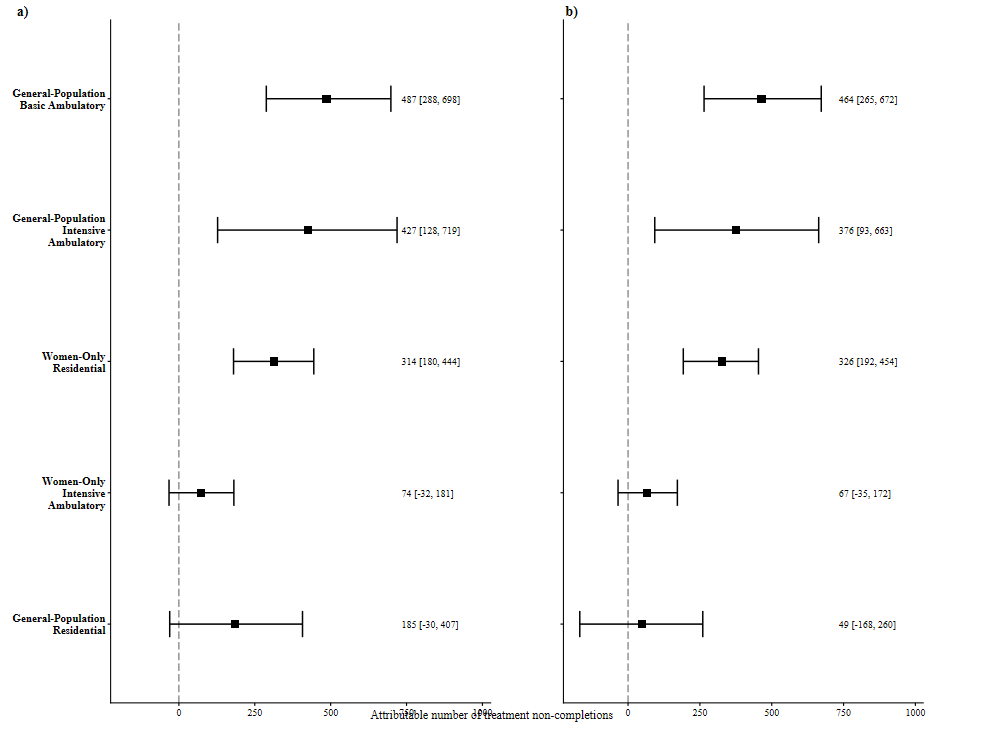

In [25]:
#| label: figure-2-attributable-counts-corrected
#| results: "hold"

## ===== Figure 2 (attributable counts) — CORRECTED MODEL (5 substances; ref = alcohol) =====
# AUDIT / CORRECTION LOG (2026-06-04). Porting of the erroneous Quarto chunk
# `boot-plot` from prop_grantt_25_postrev.qmd, audited and fixed here:
#
#  (1) MODEL BUG (same as the GEE outcome model): the Quarto bootstrap formula
#      `ff_boot` (prop_grantt_25_postrev.qmd lines 3284-3289) adjusted for primary
#      substance with only susprindum_coc + susprindum_pbc + susprindum_mar. Omitting
#      BOTH susprindum_oh (alcohol) and susprindum_oth (other) collapsed alcohol + other
#      into a single reference category. Because the attributable count comes from a
#      non-linear (logistic) model, this propagates to the counterfactual predictions.
#      FIX: restore the 4th substance indicator with ALCOHOL as reference (include
#      susprindum_oth, omit susprindum_oh), matching the corrected GEE outcome models.
#      The reference choice does not change the PSUD effect or the attributable counts
#      (verified: PSUD log-RR and fitted probabilities identical to ~1e-15).
#
#  (2) PLOTTING BUG: the Quarto code applied reorder(stratum_label, Extra_est)
#      to each panel independently, so the lag-0 and lag-1 panels could end up in a
#      DIFFERENT vertical order while only the left panel shows y-axis labels -> the
#      right panel's rows were mislabeled. FIX: both panels now share ONE stratum
#      order (taken from the lag-1 panel) so rows are aligned.
#
#  (3) AXIS BUG: the Quarto used hard-coded scale_x_continuous(limits = c(-200, 1200)),
#      which silently drops any stratum whose CI exceeds 1200. FIX: data-driven limits
#      via coord_cartesian(clip = "off").
#
#  NOTE (by design, not a bug): total_extra = sum(mu1 - mu0) is an UNWEIGHTED sum over
#  the EXPOSED episodes (not patients). The logistic fit DOES use the IIW weights; the
#  count expresses observed treatment non-completions at the episode level.
#  NOTE: boot_att_counts_safe sets set.seed(2125) at entry -> reproducible per stratum;
#  the lag-0 and lag-1 runs therefore use paired resamples.
#  Outputs are written with a `_corr` suffix so the original Quarto figure is preserved.

suppressPackageStartupMessages({
  library(dplyr); library(purrr); library(stats)
  library(ggplot2); library(cowplot)
})

#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# 1. HELPER: Safe cluster bootstrap for Attributable Risk (logistic / quasibinomial)
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
boot_att_counts_safe <- function(data, formula, weight_col = NULL, B = 2000, seed = 2125) {
  set.seed(seed)
  data$id_cluster <- as.character(data$id)
  if (!is.null(weight_col)) data$w_model <- data[[weight_col]] else data$w_model <- 1
  cl_ids <- unique(data$id_cluster)
  K <- length(cl_ids)

  # ATT on a given data set: predict factual (PSUD=1) vs counterfactual (PSUD=0)
  calc_diffs <- function(d_curr) {
    # quasibinomial(logit) keeps predicted probabilities in [0, 1] and tolerates
    # the non-integer IIW weights without the binomial non-integer-successes warning.
    fit <- try(stats::glm(formula, data = d_curr,
                          family = stats::quasibinomial(link = "logit"),
                          weights = w_model), silent = TRUE)
    if (inherits(fit, "try-error")) return(NULL)
    d_exp <- d_curr[d_curr$polysubstance_strict == 1, ]
    if (nrow(d_exp) == 0) return(NULL)
    mu1 <- predict(fit, newdata = d_exp, type = "response")
    d_unexp <- d_exp; d_unexp$polysubstance_strict <- 0
    mu0 <- predict(fit, newdata = d_unexp, type = "response")
    diffs <- mu1 - mu0
    c(total_extra = sum(diffs), risk_diff = mean(diffs), base_risk = mean(mu0))
  }

  point_est <- calc_diffs(data)
  if (is.null(point_est)) return(NULL)

  res_mat <- matrix(NA, nrow = B, ncol = 3)
  colnames(res_mat) <- c("total_extra", "risk_diff", "base_risk")
  cl_indices <- split(seq_len(nrow(data)), data$id_cluster)
  success_count <- 0L
  for (b in seq_len(B)) {
    samp_ids  <- sample(cl_ids, K, replace = TRUE)
    boot_rows <- unlist(cl_indices[samp_ids], use.names = FALSE)
    est_b <- calc_diffs(data[boot_rows, , drop = FALSE])
    if (!is.null(est_b)) { success_count <- success_count + 1L; res_mat[success_count, ] <- est_b }
  }
  res_mat <- res_mat[seq_len(success_count), , drop = FALSE]
  get_ci <- function(x) quantile(x, c(0.025, 0.5, 0.975), na.rm = TRUE)
  list(B_success = success_count, point = point_est,
       ci_total = get_ci(res_mat[, "total_extra"]),
       ci_rd    = get_ci(res_mat[, "risk_diff"]),
       ci_base  = get_ci(res_mat[, "base_risk"]))
}

#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# 2. WRAPPER across strata — CORRECTED formula (susprindum_oth added; alcohol reference and biopsych_comp_severe)
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
run_bootstrap_stratified <- function(data_full, weights = "w1_tr", B = 2000) {

  ff_boot <- tr_noncompletion ~ polysubstance_strict +
    biopsych_comp_severe + age_c10 + year_c + 
    susinidum_oh + susinidum_coc + susinidum_pbc + susinidum_mar +
    dg_psiq_cie_10_instudy + dg_psiq_cie_10_dg +
    prim_sub_daily + occ24_inactive + occ24_unemployed +
    susprindum_coc + susprindum_pbc + susprindum_mar + susprindum_oth   # <-- CORRECTION (ref = alcohol)

  split(data_full, data_full$plan_type_mod) |>
    purrr::imap(~{
      cat("Bootstrapping Stratum:", .y, "...\n")
      df <- .x |> dplyr::mutate(id = as.character(id))
      mf <- stats::model.frame(ff_boot, data = df, na.action = stats::na.pass)
      mf$w_model <- df[[weights]]
      mf$id      <- df$id
      mf <- mf[stats::complete.cases(mf), ]
      if (sum(mf$polysubstance_strict) < 10 || length(unique(mf[[1]])) < 2) {
        return(tibble::tibble(plan_type_mod = .y, note = "Insufficient data/variation"))
      }
      res <- boot_att_counts_safe(mf, ff_boot, weight_col = "w_model", B = B)
      if (is.null(res)) return(tibble::tibble(plan_type_mod = .y, note = "Fit failed"))
      tibble::tibble(
        plan_type_mod = .y,
        n_exposed = sum(mf$polysubstance_strict),
        Base_Risk_est = res$point["base_risk"] * 100,
        RD_est = res$point["risk_diff"] * 100,
        RD_lo  = res$ci_rd[1] * 100,
        RD_hi  = res$ci_rd[3] * 100,
        Extra_est = res$point["total_extra"],
        Extra_lo  = res$ci_total[1],
        Extra_hi  = res$ci_total[3],
        `Baseline Risk`  = sprintf("%.1f%%", Base_Risk_est),
        `Risk Diff (pp)` = sprintf("%.2f (%.2f, %.2f)", RD_est, RD_lo, RD_hi),
        `Extra Dropouts` = sprintf("%.0f (%.0f, %.0f)", Extra_est, Extra_lo, Extra_hi)
      )
    }) |>
    dplyr::bind_rows()
}

#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# 3. RUN bootstrap (B = 2000) for both lag-0 (w0_tr) and lag-1 (w1_tr) weights
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
set.seed(2125)
boot_results_tr1 <- run_bootstrap_stratified(dat_with_weights_stab_cons, weights = "w1_tr", B = 2000)
set.seed(2125)
boot_results_tr0 <- run_bootstrap_stratified(dat_with_weights_stab_cons, weights = "w0_tr", B = 2000)

#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# 4. FIGURE — shared stratum order across panels + data-driven x-axis
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
plan_labels <- c(
  "GP basic ambulatory"     = "General-Population\nBasic Ambulatory",
  "GP intensive ambulatory" = "General-Population\nIntensive\nAmbulatory",
  "GP residential"          = "General-Population\nResidential",
  "WO intensive ambulatory" = "Women-Only\nIntensive\nAmbulatory",
  "WO residential"          = "Women-Only\nResidential"
)

# ONE shared order for BOTH panels: ascending burden in the lag-1 (primary) panel.
shared_order_plans <- boot_results_tr1 |> dplyr::arrange(Extra_est) |> dplyr::pull(plan_type_mod)
shared_levels <- unname(plan_labels[shared_order_plans])

prepare_plot_data <- function(df, levels_order) {
  df |>
    dplyr::mutate(
      stratum_label = factor(unname(plan_labels[plan_type_mod]), levels = levels_order),
      text_label = sprintf("%.0f [%.0f, %.0f]", Extra_est, Extra_lo, Extra_hi)
    )
}
plot_data0 <- prepare_plot_data(boot_results_tr0, shared_levels)
plot_data1 <- prepare_plot_data(boot_results_tr1, shared_levels)

x_lo <- min(c(plot_data0$Extra_lo, plot_data1$Extra_lo, 0), na.rm = TRUE)
x_hi <- max(c(plot_data0$Extra_hi, plot_data1$Extra_hi), na.rm = TRUE)

create_plot <- function(data, hide_y = FALSE) {
  ggplot(data, aes(x = Extra_est, y = stratum_label)) +
    geom_vline(xintercept = 0, linetype = "longdash", color = "grey40", linewidth = 0.5) +
    geom_errorbarh(aes(xmin = Extra_lo, xmax = Extra_hi), height = 0.2, linewidth = 0.7) +
    geom_point(size = 3.5, shape = 15) +
    geom_text(aes(label = text_label), x = x_hi * 1.02, hjust = 0, family = "serif", size = 3.5) +
    labs(x = "Attributable number of treatment non-completions", y = NULL) +
    coord_cartesian(xlim = c(x_lo, x_hi * 1.35), clip = "off") +
    theme_classic(base_size = 12) +
    theme(
      text = element_text(family = "serif", color = "black"),
      axis.text.x = element_text(size = 10, color = "black"),
      axis.title.x = element_blank(),
      axis.line = element_line(linewidth = 0.5),
      axis.ticks = element_line(color = "black"),
      plot.margin = margin(t = 20, r = 60, b = 20, l = 10)
    ) +
    (if (hide_y) theme(axis.text.y = element_blank())
     else theme(axis.text.y = element_text(size = 11, color = "black", face = "bold")))
}

p_combined <- cowplot::plot_grid(
  create_plot(plot_data0, hide_y = FALSE),   # a) lag 0 (w0_tr), labels shown
  create_plot(plot_data1, hide_y = TRUE),    # b) lag 1 (w1_tr), labels shared from panel a
  labels = c("a)", "b)"), label_fontface = "bold", label_fontfamily = "serif",
  label_size = 14, label_x = 0.02, ncol = 2, align = "h", rel_widths = c(.56, .44)) +
  cowplot::draw_label("Attributable number of treatment non-completions",
                      x = 0.5, y = 0.025, hjust = 0.5, vjust = 0, size = 12, fontfamily = "serif")
print(p_combined)

fig_dir <- file.path(getwd(), "_figs")
data_dir <- file.path(getwd(), "output")

dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(data_dir, recursive = TRUE, showWarnings = FALSE)

save(
  boot_results_tr1,
  file = file.path(data_dir, "boot_results_safe_tr1_corr.RData")
)

save(
  boot_results_tr0,
  file = file.path(data_dir, "boot_results_safe_tr0_corr.RData")
)

ggsave(
  file.path(fig_dir, "figure_attributable_counts_corr.png"),
  plot = p_combined,
  width = 8,
  height = 5,
  dpi = 600
)

ggsave(
  file.path(fig_dir, "figure_attributable_counts_corr.pdf"),
  plot = p_combined,
  width = 8,
  height = 5
)

old_tr1_path <- file.path(getwd(), "output", "boot_results_safe_tr1.RData")

~ 46 minutes

In [26]:
#| label: bootstrap-attributable-counts-corrected-table
#| results: "hold"

## ===== Figure 2: results table + comparison (previous vs. corrected version) =====
# Primary display table = lag 1, like the Quarto `boot_table` chunk.
boot_results <- boot_results_tr1
print(knitr::kable(
  boot_results |>
    dplyr::select(plan_type_mod, n_exposed, `Baseline Risk`, `Risk Diff (pp)`, `Extra Dropouts`),
  format = "pipe",
  caption = "Attributable risk of PSUD (corrected logistic bootstrap, alcohol reference, lag 1)"
))
cat("\nTotal attributable treatment non-completions (lag 1):", round(sum(boot_results$Extra_est)), "\n")




Table: Attributable risk of PSUD (corrected logistic bootstrap, alcohol reference, lag 1)

|plan_type_mod           | n_exposed|Baseline Risk |Risk Diff (pp)     |Extra Dropouts |
|:-----------------------|---------:|:-------------|:------------------|:--------------|
|GP basic ambulatory     |     14582|76.0%         |3.18 (1.83, 4.59)  |464 (265, 672) |
|GP intensive ambulatory |     20904|75.5%         |1.80 (0.44, 3.17)  |376 (93, 663)  |
|GP residential          |      8496|71.4%         |0.57 (-1.96, 3.05) |49 (-168, 260) |
|WO intensive ambulatory |      3376|74.2%         |1.99 (-1.05, 5.08) |67 (-35, 172)  |
|WO residential          |      4213|68.0%         |7.74 (4.58, 10.71) |326 (192, 454) |

Total attributable treatment non-completions (lag 1): 1282 


## Sensitivity model: AUD vs non-AUD adjusted for PSUD

Reviewer 2 raised the possibility that the PSUD association could be driven by the primary substance composition of the comparison group. Lappan, Brown, and Hendricks (2020) reported substantial heterogeneity in dropout across in-person psychosocial SUD treatment studies, including variation by target substance. This motivates an explicit sensitivity model that includes primary AUD status and PSUD status in the same modified Poisson GEE.

Reference: Lappan SN, Brown AW, Hendricks PS. Dropout rates of in-person psychosocial substance use disorder treatments: a systematic review and meta-analysis. *Addiction*. 2020;115(2):201-217. doi:10.1111/add.14793.


In [24]:
#| label: aud-vs-non-aud-gee-model
#| results: "hold"

# Phase 1: Build the analysis dataset and standardize key identifiers
analysis_dat <- as.data.frame(dat_with_weights_stab_cons)
analysis_dat$id <- as.character(analysis_dat$id)

# Phase 2: Create missing covariates only if they are not already present
if (!"occ24_inactive" %in% names(analysis_dat)) {
  analysis_dat$occ24_inactive <- as.integer(analysis_dat$occupation_condition_corr24 == "inactive")
}

if (!"occ24_unemployed" %in% names(analysis_dat)) {
  analysis_dat$occ24_unemployed <- as.integer(analysis_dat$occupation_condition_corr24 == "unemployed")
}

if (!"susinidum_coc" %in% names(analysis_dat)) {
  analysis_dat$susinidum_coc <- as.integer(analysis_dat$sus_ini_mod_mvv == "cocaine powder")
}

if (!"susinidum_pbc" %in% names(analysis_dat)) {
  analysis_dat$susinidum_pbc <- as.integer(analysis_dat$sus_ini_mod_mvv == "cocaine paste")
}

if (!"susinidum_mar" %in% names(analysis_dat)) {
  analysis_dat$susinidum_mar <- as.integer(analysis_dat$sus_ini_mod_mvv == "marijuana")
}

if (!"susinidum_oh" %in% names(analysis_dat)) {
  analysis_dat$susinidum_oh <- as.integer(analysis_dat$sus_ini_mod_mvv == "alcohol")
}

if (!"age_c10" %in% names(analysis_dat)) {
  analysis_dat$age_c10 <- (analysis_dat$adm_age_rec3 - mean(analysis_dat$adm_age_rec3, na.rm = TRUE)) / 10
}

if (!"year_c" %in% names(analysis_dat)) {
  analysis_dat$year_c <- analysis_dat$year_decimal - 2015 #birth year of data, centered for interpretability
}

# Phase 3: Define the primary AUD indicator
analysis_dat$primary_aud <- as.integer(
  analysis_dat$susprindum_oh == 1 | as.character(analysis_dat$primary_sub_mod) == "alcohol"
)

# Phase 4: Define a reusable GEE model-fitting function
fit_aud_psud_gee <- function(df, label, weight_col = "w1_tr", include_plan = FALSE) {

  # Phase 4a: Select candidate adjustment variables
  candidate_terms <- c(
    "polysubstance_strict", "biopsych_comp_severe", "primary_aud", "age_c10", "year_c", # 2026-06-07= added biopsychosocial severity
    "susinidum_coc", "susinidum_pbc", "susinidum_mar", "susinidum_oh", # 2026-06-07= added alcohol indicator (ref category for substance onset type: others)
    "dg_psiq_cie_10_instudy", "dg_psiq_cie_10_dg",
    "prim_sub_daily", "occ24_inactive", "occ24_unemployed"
  )

  # Phase 4b: Optionally adjust for treatment setting / plan type
  if (include_plan) candidate_terms <- c(candidate_terms, "plan_type_mod")

  # Phase 4c: Keep only variables that exist in the current dataset
  candidate_terms <- intersect(candidate_terms, names(df))
  ff <- stats::reformulate(candidate_terms, response = "tr_noncompletion")

  # Phase 4d: Build the model frame and define complete-case rows
  mf0 <- stats::model.frame(ff, data = df, na.action = stats::na.pass)
  keep <- stats::complete.cases(mf0) & !is.na(df$id)

  # Phase 4e: Apply weight eligibility rules when weights are used
  if (!is.null(weight_col) && weight_col %in% names(df)) {
    keep <- keep & is.finite(df[[weight_col]]) & !is.na(df[[weight_col]]) & df[[weight_col]] > 0
  }

  mf <- mf0[keep, , drop = FALSE]

  # Phase 4f: Stop if there are no usable rows or no outcome variation
  if (nrow(mf) == 0L || length(unique(stats::model.response(mf))) < 2L) return(NULL)

  # Phase 4g: Build the design matrix and identify model terms
  X <- stats::model.matrix(ff, mf)
  assign_vec <- attr(X, "assign")
  term_labels <- attr(stats::terms(ff), "term.labels")

  # Phase 4h: Remove constant predictors, keeping the intercept
  const <- vapply(as.data.frame(X), function(v) length(unique(v)) == 1L, logical(1))
  const[colnames(X) == "(Intercept)"] <- FALSE

  if (any(const)) {
    X <- X[, !const, drop = FALSE]
    assign_vec <- assign_vec[!const]
  }

  # Phase 4i: Remove linearly dependent terms using QR decomposition
  qrX <- qr(X)
  keep_cols <- sort(qrX$pivot[seq_len(qrX$rank)])
  kept_term_idx <- sort(unique(assign_vec[keep_cols][assign_vec[keep_cols] > 0]))
  kept_terms <- term_labels[kept_term_idx]
  ff_reduced <- stats::reformulate(kept_terms, response = "tr_noncompletion")

  # Phase 4j: Clean weights for the final model
  weights_vec <- NULL

  if (!is.null(weight_col) && weight_col %in% names(df)) {
    weights_vec <- clean_weights(df[[weight_col]][keep])
  }

  # Phase 4k: Fit modified Poisson GEE with independent working correlation
  fit <- geepack::geeglm(
    ff_reduced,
    id = df$id[keep],
    data = mf,
    weights = weights_vec,
    family = poisson(link = "log"),
    corstr = "independence",
    scale.fix = TRUE,
    na.action = stats::na.exclude
  )

  # Phase 4l: Return only the main contrasts of interest
  broom::tidy(fit, exponentiate = TRUE, conf.int = TRUE) |>
    dplyr::filter(term %in% c("polysubstance_strict", "primary_aud")) |>
    dplyr::transmute(
      model = label,
      weight = ifelse(is.null(weight_col), "unweighted", weight_col),
      n_rows = nrow(mf),
      n_patients = dplyr::n_distinct(df$id[keep]),
      term = dplyr::recode(
        term,
        polysubstance_strict = "PSUD vs single SUD",
        primary_aud = "Primary AUD vs non-AUD"
      ),
      RR = estimate,
      conf_low = conf.low,
      conf_high = conf.high,
      p_value = p.value,
      `RR (95% CI)` = sprintf("%.2f (%.2f, %.2f)", estimate, conf.low, conf.high)
    )
}

# Phase 5: Fit the overall weighted model adjusted for treatment setting
aud_sens_overall_w1 <- fit_aud_psud_gee(
  analysis_dat,
  label = "Overall, adjusted for treatment setting",
  weight_col = "w1_tr",
  include_plan = TRUE
)

# Phase 6: Fit weighted models separately within each treatment setting
aud_sens_by_plan_w1 <- analysis_dat |>
  split(analysis_dat$plan_type_mod) |>
  purrr::imap(~ fit_aud_psud_gee(.x, label = as.character(.y), weight_col = "w1_tr", include_plan = FALSE)) |>
  dplyr::bind_rows()

# Phase 7: Define the display order for model results
model_order <- c(
  "Overall, adjusted for treatment setting",
  sort(unique(as.character(analysis_dat$plan_type_mod)))
)

# Phase 8: Combine and order all sensitivity model results
aud_psud_sensitivity_results <- dplyr::bind_rows(aud_sens_overall_w1, aud_sens_by_plan_w1) |>
  dplyr::arrange(match(model, model_order), term)

# Phase 9: Optional export of sensitivity results
# write.csv(
#   aud_psud_sensitivity_results,
#   file.path(out_dir, "sensitivity_aud_vs_nonaud_adjusted_for_psud_w1.csv"),
#   row.names = FALSE,
#   fileEncoding = "UTF-8"
# )

# Phase 10: Render the final results table
knitr::kable(
  aud_psud_sensitivity_results |>
    dplyr::select(model, weight, n_rows, n_patients, term, `RR (95% CI)`, p_value),
  format = "pipe",
  digits = 4,
  caption = "Sensitivity model: primary AUD vs non-AUD adjusted for PSUD, weighted lag 1 modified Poisson GEE."
)



Table: Sensitivity model: primary AUD vs non-AUD adjusted for PSUD, weighted lag 1 modified Poisson GEE.

|model                                   |weight | n_rows| n_patients|term                   |RR (95% CI)       | p_value|
|:---------------------------------------|:------|------:|----------:|:----------------------|:-----------------|-------:|
|Overall, adjusted for treatment setting |w1_tr  |  67957|      27445|PSUD vs single SUD     |1.05 (1.04, 1.06) |  0.0000|
|Overall, adjusted for treatment setting |w1_tr  |  67957|      27445|Primary AUD vs non-AUD |0.95 (0.94, 0.96) |  0.0000|
|GP basic ambulatory                     |w1_tr  |  20753|       8570|PSUD vs single SUD     |1.06 (1.03, 1.08) |  0.0000|
|GP basic ambulatory                     |w1_tr  |  20753|       8570|Primary AUD vs non-AUD |0.96 (0.93, 0.98) |  0.0000|
|GP intensive ambulatory                 |w1_tr  |  26825|      10975|PSUD vs single SUD     |1.04 (1.02, 1.06) |  0.0004|
|GP intensive ambulatory       

## Whole-population GEE and Table S7

In [ ]:
#| label: all-pop-setup-trajectory
#| echo: true
#| warning: false
#| message: true
#| results: "hold"

coerce_date <- function(x) {
  if (inherits(x, "Date")) {
    x
  } else if (is.numeric(x)) {
    as.Date(x, origin = "1970-01-01")
  } else {
    as.Date(x)
  }
}

cap <- function(w, p = c(0.025, 0.975)) {
  b <- stats::quantile(w, probs = p, na.rm = TRUE)
  pmin(pmax(w, b[1]), b[2])
}

clean_weights <- function(w) {
  w[!is.finite(w) | is.na(w) | w <= 0] <- 1
  w / mean(w, na.rm = TRUE)
}

extract_weights <- function(iiw_by_plan, dat, weight_name = "iiw.weight",
                            out_col = "iiw_weight", na_to_one = TRUE) {
  weights_list <- lapply(names(iiw_by_plan), function(pt) {
    mod <- iiw_by_plan[[pt]]
    dat_sub <- dat[dat$plan_type_mod == pt, , drop = FALSE]

    if (!weight_name %in% names(mod)) {
      stop(sprintf("Weight '%s' not found for plan type '%s'", weight_name, pt))
    }

    w <- mod[[weight_name]]

    if (length(w) != nrow(dat_sub)) {
      stop(sprintf(
        "Row mismatch for %s: %d weights vs %d rows",
        pt, length(w), nrow(dat_sub)
      ))
    }

    if (na_to_one) w[is.na(w)] <- 1
    dat_sub[[out_col]] <- w
    dat_sub
  })

  do.call(rbind, weights_list)
}

if (!exists("SISTRAT_clean_drop_patient")) {
  wd <- normalizePath(getwd(), winslash = "/", mustWork = FALSE)
  wdpath <- if (grepl("SISTRAT 2023", wd)) {
    paste0(gsub("/cons", "", gsub("cons", "", paste0(wd, "/cons"))))
  } else {
    paste0(
      gsub("/SISTRAT 2022 \\(github\\)/_proposal_grant/2023", "", wd),
      "/SISTRAT 2023/"
    )
  }

  rdata_file <- file.path(
    wdpath,
    "data",
    "20241015_out",
    "psu",
    "psu_ndp_2025_10_02.Rdata"
  )

  stopifnot(file.exists(rdata_file))
  load(rdata_file)
}

allpop0 <- as.data.frame(SISTRAT_clean_drop_patient)

allpop0$adm_date_rec2 <- coerce_date(allpop0$adm_date_rec2)
allpop0$disch_date_rec6 <- coerce_date(allpop0$disch_date_rec6)

if (!"censor_date" %in% names(allpop0)) {
  allpop0$censor_date <- as.Date("2025-05-28")
}

allpop0$treat_log_days[!is.finite(allpop0$treat_log_days)] <- NA_real_

vars_allpop_cc <- c(
  "hash_key", "rn", "adm_date_rec2", "disch_date_rec6", "censor_date",
  "tr_noncompletion", "polysubstance_strict", "biopsych_comp_severe",
  "treat_lt_90", "treat_log_days", "adm_age_rec3", "year_decimal",
  "sus_ini_mod_mvv", "dg_psiq_cie_10_instudy", "dg_psiq_cie_10_dg",
  "prim_sub_daily", "occupation_condition_corr24", "primary_sub_mod",
  "plan_type_mod"
)

stopifnot(all(vars_allpop_cc %in% names(allpop0)))

allpop_traj <- allpop0[stats::complete.cases(allpop0[, vars_allpop_cc]), ] |>
  dplyr::arrange(hash_key, adm_date_rec2, disch_date_rec6) |>
  dplyr::group_by(hash_key) |>
  dplyr::mutate(
    treatment = dplyr::row_number(),
    enter_date = min(adm_date_rec2, na.rm = TRUE),
    time = lubridate::time_length(
      lubridate::interval(enter_date, disch_date_rec6),
      unit = "months"
    ),
    cens_time = lubridate::time_length(
      lubridate::interval(enter_date, censor_date),
      unit = "months"
    )
  ) |>
  dplyr::ungroup() |>
  dplyr::group_by(hash_key, time) |>
  dplyr::mutate(
    dup_idx = dplyr::row_number()
  ) |>
  dplyr::ungroup() |>
  dplyr::mutate(
    time = time + (dup_idx - 1L) * 0.001,
    id = as.character(as.numeric(factor(hash_key))),
    event_vis = 1L,
    tr_outcome = as.integer(tr_noncompletion),
    occ24_inactive = as.integer(occupation_condition_corr24 == "inactive"),
    occ24_unemployed = as.integer(occupation_condition_corr24 == "unemployed"),
    susinidum_oh = as.integer(sus_ini_mod_mvv == "alcohol"),
    susinidum_coc = as.integer(sus_ini_mod_mvv == "cocaine powder"),
    susinidum_pbc = as.integer(sus_ini_mod_mvv == "cocaine paste"),
    susinidum_mar = as.integer(sus_ini_mod_mvv == "marijuana"),
    susprindum_oth = as.integer(sus_ini_mod_mvv == "others"),
    susprindum_oh = as.integer(primary_sub_mod == "alcohol"),
    susprindum_coc = as.integer(primary_sub_mod == "cocaine powder"),
    susprindum_pbc = as.integer(primary_sub_mod == "cocaine paste"),
    susprindum_mar = as.integer(primary_sub_mod == "marijuana"),
    susprindum_oth = as.integer(primary_sub_mod == "others"),
    year_c = year_decimal - 2015,
    age_c10 = (adm_age_rec3 - mean(adm_age_rec3, na.rm = TRUE)) / 10
  ) |>
  dplyr::select(-dup_idx)

plan_types <- c(
  "GP basic ambulatory",
  "GP intensive ambulatory",
  "GP residential",
  "WO intensive ambulatory",
  "WO residential"
)

plan_types <- intersect(plan_types, unique(as.character(allpop_traj$plan_type_mod)))

cat("Whole-population complete-case rows:", nrow(allpop_traj), "\n")
cat("Whole-population complete-case patients:", dplyr::n_distinct(allpop_traj$hash_key), "\n")

tab_all <- table(SISTRAT_clean_drop_patient[["hash_key"]])
cat("Patients with one observed admission in source:", sum(tab_all == 1), "\n")
cat("Patients with multiple observed admissions in source:", sum(tab_all > 1), "\n")

Whole-population complete-case rows: 149877 
Whole-population complete-case patients: 110715 
Patients with one observed admission in source: 91149 
Patients with multiple observed admissions in source: 27445 


In [38]:
#| label: all-pop-iiw-weights
#| echo: true
#| warning: true
#| message: true
#| results: "hold"

post_all_dat <- data.table::as.data.table(allpop_traj)
data.table::setorder(post_all_dat, id, time)

eps <- 1e-3
post_all_dat[, .idx := seq_len(.N) - 1L, by = .(id, time)]
post_all_dat[, time := time + eps * .idx][, .idx := NULL]
post_all_dat[, time.lag := data.table::shift(time, type = "lag", fill = 0), by = id]
post_all_dat[time <= time.lag, time := time.lag + eps]

post_all_maxfu_df <- post_all_dat[, .(maxfu.time = max(cens_time, na.rm = TRUE)), by = .(maxfu.id = id)]
data.table::setDF(post_all_dat)
post_all_maxfu_df <- as.data.frame(post_all_maxfu_df)

iiw_formula <- survival::Surv(time.lag, time, event_vis) ~
  tr_noncompletion.lag + biopsych_comp_severe.lag +
  treat_lt_90.lag + treat_log_days.lag + polysubstance_strict.lag +
  age_c10 + year_c +
  susinidum_oh + susinidum_coc + susinidum_pbc + susinidum_mar +
  dg_psiq_cie_10_instudy + dg_psiq_cie_10_dg + prim_sub_daily +
  occ24_inactive + occ24_unemployed +
  susprindum_oh + susprindum_coc + susprindum_pbc + susprindum_mar +
  survival::cluster(id)

run_iiw_plan <- function(pt, lagfirst_vec) {
  cat("Running IIW for:", pt, "\n")
  dat_sub <- post_all_dat |> dplyr::filter(plan_type_mod == pt) |> as.data.frame()
  maxfu_sub <- post_all_maxfu_df[post_all_maxfu_df$maxfu.id %in% dat_sub$id, , drop = FALSE]

  IrregLong::iiw.weights(
    formulaph = iiw_formula,
    data = dat_sub,
    id = "id",
    time = "time",
    event = "event_vis",
    lagvars = c(
      "time", "tr_noncompletion", "biopsych_comp_severe",
      "treat_lt_90", "treat_log_days", "polysubstance_strict"
    ),
    invariant = "id",
    maxfu = maxfu_sub,
    lagfirst = lagfirst_vec,
    first = TRUE
  )
}

lagfirst0 <- c(5.149111, 0, 0, 0, log(15 + 1), 0)
lagfirst1 <- c(5.149111, 1, 1, 1, log(90 + 1), 1)

post_all_iiw_by_plan0 <- lapply(plan_types, run_iiw_plan, lagfirst_vec = lagfirst0)
names(post_all_iiw_by_plan0) <- plan_types

post_all_iiw_by_plan1 <- lapply(plan_types, run_iiw_plan, lagfirst_vec = lagfirst1)
names(post_all_iiw_by_plan1) <- plan_types

post_all_w0 <- extract_weights(post_all_iiw_by_plan0, post_all_dat, out_col = "iiw_weight0_stab")
post_all_w1 <- extract_weights(post_all_iiw_by_plan1, post_all_dat, out_col = "iiw_weight1_stab")

post_all_dat_with_weights <- post_all_w0 |>
  dplyr::left_join(post_all_w1[, c("rn", "iiw_weight1_stab")], by = "rn") |>
  dplyr::mutate(
    iiw_weight0_stab = dplyr::if_else(is.na(iiw_weight0_stab) & time.lag == 0, 1, iiw_weight0_stab),
    iiw_weight1_stab = dplyr::if_else(is.na(iiw_weight1_stab) & time.lag == 0, 1, iiw_weight1_stab),
    w0_tr = cap(iiw_weight0_stab, c(0.025, 0.975)),
    w1_tr = cap(iiw_weight1_stab, c(0.025, 0.975))
  )

allpop_weight_summary <- dplyr::bind_rows(
  data.frame(weight = "lag0", t(as.matrix(summary(post_all_dat_with_weights$w0_tr))), check.names = FALSE),
  data.frame(weight = "lag1", t(as.matrix(summary(post_all_dat_with_weights$w1_tr))), check.names = FALSE)
)

knitr::kable(allpop_weight_summary, digits = 2, caption = "Whole-population inverse-intensity weights.")

Running IIW for: GP basic ambulatory 
Running IIW for: GP intensive ambulatory 
Running IIW for: GP residential 
Running IIW for: WO intensive ambulatory 
Running IIW for: WO residential 


Warning messages:
1: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created
2: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created
3: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created
4: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created
5: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created


Running IIW for: GP basic ambulatory 
Running IIW for: GP intensive ambulatory 
Running IIW for: GP residential 
Running IIW for: WO intensive ambulatory 
Running IIW for: WO residential 


Warning messages:
1: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created
2: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created
3: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created
4: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created
5: In survival::Surv(time.lag, time, event_vis) :
  Stop time must be > start time, NA created




Table: Whole-population inverse-intensity weights.

|weight | Min.| 1st Qu.| Median| Mean| 3rd Qu.| Max.|
|:------|----:|-------:|------:|----:|-------:|----:|
|lag0   | 1.00|       1|      1| 1.63|    1.52| 5.42|
|lag1   | 0.27|       1|      1| 0.89|    1.00| 1.00|

In [42]:
#| label: all-pop-s7-gee-results
#| echo: true
#| warning: false
#| message: false
#| results: "hold"

outcome_terms <- c(
  "polysubstance_strict",
  "biopsych_comp_severe",
  "age_c10",
  "year_c",
  "susinidum_oh",
  "susinidum_coc",
  "susinidum_pbc",
  "susinidum_mar",
  "dg_psiq_cie_10_instudy",
  "dg_psiq_cie_10_dg",
  "prim_sub_daily",
  "occ24_inactive",
  "occ24_unemployed",
  "susprindum_coc",
  "susprindum_pbc",
  "susprindum_mar",
  "susprindum_oth"
)

reduce_formula <- function(ff, mf) {
  X <- stats::model.matrix(ff, mf)
  assign_vec <- attr(X, "assign")
  term_labels <- attr(stats::terms(ff), "term.labels")

  const <- vapply(as.data.frame(X), function(v) length(unique(v)) == 1L, logical(1))
  const[colnames(X) == "(Intercept)"] <- FALSE

  if (any(const)) {
    X <- X[, !const, drop = FALSE]
    assign_vec <- assign_vec[!const]
  }

  qrX <- qr(X)
  keep_cols <- sort(qrX$pivot[seq_len(qrX$rank)])
  kept_term_idx <- sort(unique(assign_vec[keep_cols][assign_vec[keep_cols] > 0]))
  kept_terms <- term_labels[kept_term_idx]

  if (!"polysubstance_strict" %in% kept_terms) {
    stop("polysubstance_strict was dropped from the model.")
  }

  stats::reformulate(kept_terms, response = "tr_noncompletion")
}

fit_allpop_plan <- function(df, plan_label, weight_name) {
  df <- dplyr::mutate(df, id = as.character(id))

  ff <- stats::reformulate(outcome_terms, response = "tr_noncompletion")
  mf0 <- stats::model.frame(ff, data = df, na.action = stats::na.pass)

  keep <- stats::complete.cases(mf0) &
    !is.na(df$id) &
    is.finite(df[[weight_name]]) &
    !is.na(df[[weight_name]]) &
    df[[weight_name]] > 0

  mf <- mf0[keep, , drop = FALSE]

  if (nrow(mf) == 0L || length(unique(stats::model.response(mf))) < 2L) {
    return(NULL)
  }

  ff_reduced <- reduce_formula(ff, mf)

  mf$.__w <- clean_weights(df[[weight_name]][keep])
  mf$.__id <- df$id[keep]
  mf$.__hash_key <- df$hash_key[keep]

  fit <- geepack::geeglm(
    formula = ff_reduced,
    id = .__id,
    data = mf,
    family = stats::poisson(link = "log"),
    corstr = "independence",
    scale.fix = TRUE,
    na.action = stats::na.exclude,
    weights = .__w
  )

  broom::tidy(fit, exponentiate = TRUE, conf.int = TRUE) |>
    dplyr::filter(term == "polysubstance_strict") |>
    dplyr::transmute(
      plan_type_mod = plan_label,
      n_rows = nrow(mf),
      n_patients = dplyr::n_distinct(mf$.__hash_key),
      weight = weight_name,
      RR = estimate,
      conf_low = conf.low,
      conf_high = conf.high,
      p_value = p.value,
      `RR (95% CI)` = sprintf("%.2f (%.2f, %.2f)", estimate, conf.low, conf.high)
    )
}

allpop_results_list <- list()

for (weight_name_i in c("w0_tr", "w1_tr")) {
  for (plan_i in sort(unique(as.character(post_all_dat_with_weights$plan_type_mod)))) {
    df_i <- post_all_dat_with_weights[
      as.character(post_all_dat_with_weights$plan_type_mod) == plan_i,
      ,
      drop = FALSE
    ]

    allpop_results_list[[paste(weight_name_i, plan_i, sep = "__")]] <-
      fit_allpop_plan(
        df = df_i,
        plan_label = plan_i,
        weight_name = weight_name_i
      )
  }
}

allpop_results_long <- dplyr::bind_rows(allpop_results_list)

setting_labels <- c(
  "GP basic ambulatory" = "Basic ambulatory",
  "GP intensive ambulatory" = "General-population, intensive ambulatory",
  "GP residential" = "General-population, residential",
  "WO intensive ambulatory" = "Women-only, intensive ambulatory",
  "WO residential" = "Women-only, residential"
)

allpop_s7 <- allpop_results_long |>
  dplyr::mutate(
    `Baseline treatment setting` = unname(setting_labels[plan_type_mod]),
    weight = dplyr::recode(weight, w0_tr = "lag0", w1_tr = "lag1")
  ) |>
  dplyr::select(`Baseline treatment setting`, weight, `RR (95% CI)`) |>
  tidyr::pivot_wider(names_from = weight, values_from = `RR (95% CI)`) |>
  dplyr::arrange(match(`Baseline treatment setting`, unname(setting_labels))) |>
  dplyr::rename(
    `Inverse intensity weighted RR (95% CI) (lag0)` = lag0,
    `Inverse intensity weighted RR (95% CI) (lag1)` = lag1
  )

knitr::kable(
  allpop_s7,
  format = "markdown",
  caption = "Table S7. Association between polysubstance use disorder at admission and treatment non-completion status, including patients with only one treatment admission."
) |> print()

cat("Rows in weighted whole-population data:", nrow(post_all_dat_with_weights), "\n")
cat("Patients in weighted whole-population data:", dplyr::n_distinct(post_all_dat_with_weights$hash_key), "\n")



Table: Table S7. Association between polysubstance use disorder at admission and treatment non-completion status, including patients with only one treatment admission.

|Baseline treatment setting               |Inverse intensity weighted RR (95% CI) (lag0) |Inverse intensity weighted RR (95% CI) (lag1) |
|:----------------------------------------|:---------------------------------------------|:---------------------------------------------|
|Basic ambulatory                         |1.07 (1.05, 1.09)                             |1.08 (1.07, 1.09)                             |
|General-population, intensive ambulatory |1.06 (1.04, 1.08)                             |1.07 (1.05, 1.08)                             |
|General-population, residential          |1.03 (0.99, 1.06)                             |1.01 (0.98, 1.04)                             |
|Women-only, intensive ambulatory         |1.07 (1.02, 1.11)                             |1.08 (1.05, 1.12)                             |
|

In [45]:
#| label: s6-gee-results-best-qic
#| echo: true
#| warning: false
#| message: false
#| results: "hold"

# Supplemental Table S6: QIC model selection in multiple-treatment population
# No library() calls. Use package::function syntax only.

if (!exists("dat_with_weights_stab_cons")) {
  rds_candidates <- c(
    "data/dat_with_weights_stab_cons.rds",
    "output/dat_with_weights_stab_cons.rds",
    "cons/dat_with_weights_stab_cons.rds"
  )

  rdata_candidates <- c(
    "data/dat_with_weights_stab_cons.RData",
    "output/dat_with_weights_stab_cons.RData",
    "cons/dat_with_weights_stab_cons.RData"
  )

  rds_hit <- rds_candidates[file.exists(rds_candidates)]
  rdata_hit <- rdata_candidates[file.exists(rdata_candidates)]

  if (length(rds_hit) > 0) {
    dat_with_weights_stab_cons <- base::readRDS(rds_hit[1])
  } else if (length(rdata_hit) > 0) {
    base::load(rdata_hit[1])
  } else {
    stop("dat_with_weights_stab_cons is not in memory and no candidate .rds/.RData file was found.")
  }
}

s6_dat <- as.data.frame(dat_with_weights_stab_cons)

if (!"age_c10" %in% names(s6_dat)) {
  s6_dat$age_c10 <- (s6_dat$age_at_admission - mean(s6_dat$age_at_admission, na.rm = TRUE)) / 10
}

if (!"year_c" %in% names(s6_dat)) {
  s6_dat$year_c <- s6_dat$year - mean(s6_dat$year, na.rm = TRUE)
}

if (!"occ24_inactive" %in% names(s6_dat)) {
  s6_dat$occ24_inactive <- as.integer(s6_dat$occupation_condition_corr24 == "inactive")
}

if (!"occ24_unemployed" %in% names(s6_dat)) {
  s6_dat$occ24_unemployed <- as.integer(s6_dat$occupation_condition_corr24 == "unemployed")
}

if (!"susprindum_oth" %in% names(s6_dat)) {
  s6_dat$susprindum_oth <- as.integer(s6_dat$primary_sub_mod == "others")
}

clean_weights <- function(w) {
  w <- as.numeric(w)
  w[!is.finite(w) | is.na(w) | w <= 0] <- NA_real_
  w
}

s6_terms <- c(
  "polysubstance_strict",
  "biopsych_comp_severe",
  "age_c10",
  "year_c",
  "susinidum_oh",
  "susinidum_coc",
  "susinidum_pbc",
  "susinidum_mar",
  "dg_psiq_cie_10_instudy",
  "dg_psiq_cie_10_comorbid",
  "freq_cons_sus_prin_daily",
  "occ24_inactive",
  "occ24_unemployed",
  "susprindum_coc",
  "susprindum_pbc",
  "susprindum_mar",
  "susprindum_oth"
)

reduce_formula_s6 <- function(formula_in, model_frame) {
  y_name <- all.vars(formula_in)[1]
  x_names <- setdiff(names(model_frame), y_name)

  keep_x <- x_names[vapply(
    x_names,
    function(x) length(unique(model_frame[[x]][!is.na(model_frame[[x]])])) > 1,
    logical(1)
  )]

  stats::reformulate(keep_x, response = y_name)
}

fit_s6_plan <- function(df, plan_label, weight_name = NULL, weight_label = "No weights") {
  if (!"id" %in% names(df)) {
    df$id <- df$hash_key
  }

  df$id <- as.character(df$id)
  terms_here <- intersect(s6_terms, names(df))

  formula0 <- stats::reformulate(terms_here, response = "tr_noncompletion")
  mf0 <- stats::model.frame(formula0, data = df, na.action = stats::na.pass)

  keep <- stats::complete.cases(mf0) & !is.na(df$id)

  if (!is.null(weight_name)) {
    if (!weight_name %in% names(df)) {
      stop(paste0("Weight column not found: ", weight_name))
    }

    w_raw <- clean_weights(df[[weight_name]])
    keep <- keep & !is.na(w_raw)
  }

  mf <- mf0[keep, , drop = FALSE]

  if (nrow(mf) == 0 || length(unique(stats::model.response(mf))) < 2) {
    return(tibble::tibble(
      plan_type_mod = plan_label,
      weight = weight_label,
      n_rows = nrow(mf),
      n_patients = NA_integer_,
      QIC = NA_real_,
      RR = NA_real_,
      conf_low = NA_real_,
      conf_high = NA_real_,
      p_value = NA_real_,
      `RR (95% CI)` = NA_character_
    ))
  }

  formula_fit <- reduce_formula_s6(formula0, mf)

  mf$.__id <- df$id[keep]
  mf$.__hash_key <- df$hash_key[keep]
  mf$.__w <- if (is.null(weight_name)) {
    rep(1, nrow(mf))
  } else {
    clean_weights(df[[weight_name]][keep])
  }

  fit <- geepack::geeglm(
    formula = formula_fit,
    id = .__id,
    data = mf,
    weights = .__w,
    family = stats::poisson(link = "log"),
    corstr = "independence",
    scale.fix = TRUE,
    na.action = stats::na.exclude
  )

  qic_out <- tryCatch(
    geepack::QIC(fit),
    error = function(e) c(QIC = NA_real_)
  )

  rr_out <- broom::tidy(fit, exponentiate = TRUE, conf.int = TRUE)

  psu_row <- dplyr::filter(rr_out, term == "polysubstance_strict")

  tibble::tibble(
    plan_type_mod = plan_label,
    weight = weight_label,
    n_rows = nrow(mf),
    n_patients = dplyr::n_distinct(mf$.__hash_key),
    QIC = unname(qic_out["QIC"]),
    RR = psu_row$estimate[1],
    conf_low = psu_row$conf.low[1],
    conf_high = psu_row$conf.high[1],
    p_value = psu_row$p.value[1],
    `RR (95% CI)` = sprintf(
      "%.2f (%.2f, %.2f)",
      psu_row$estimate[1],
      psu_row$conf.low[1],
      psu_row$conf.high[1]
    )
  )
}

setting_order <- c(
  "GP basic ambulatory",
  "GP intensive ambulatory",
  "GP residential",
  "W basic ambulatory",
  "W intensive ambulatory",
  "W residential"
)

base::sort(unique(as.character(s6_dat$plan_type_mod)))

setting_order <- c(
  "GP basic ambulatory",
  "GP intensive ambulatory",
  "GP residential",
  "WO intensive ambulatory",
  "WO residential"
)

setting_order <- setting_order[setting_order %in% unique(as.character(s6_dat$plan_type_mod))]

setting_labels <- c(
  "GP basic ambulatory" = "Basic ambulatory",
  "GP intensive ambulatory" = "General-population, intensive ambulatory",
  "GP residential" = "General-population, residential",
  "WO intensive ambulatory" = "Women-only, intensive ambulatory",
  "WO residential" = "Women-only, residential"
)

weight_specs <- list(
  "No weights" = NULL,
  "lag=0" = "w0_tr",
  "lag=1" = "w1_tr"
)

s6_results <- list()

for (plan_i in setting_order) {
  df_i <- dplyr::filter(s6_dat, plan_type_mod == plan_i)

  for (weight_label_i in names(weight_specs)) {
    weight_name_i <- weight_specs[[weight_label_i]]

    s6_results[[paste(plan_i, weight_label_i, sep = "__")]] <- fit_s6_plan(
      df = df_i,
      plan_label = plan_i,
      weight_name = weight_name_i,
      weight_label = weight_label_i
    )
  }
}

s6_results_long <- dplyr::bind_rows(s6_results)

s6_table <- s6_results_long |>
  dplyr::mutate(
    `Baseline treatment setting` = unname(setting_labels[plan_type_mod]),
    `IIW weights` = weight,
    QIC = dplyr::if_else(
      is.na(QIC),
      NA_character_,
      base::formatC(
        as.integer(round(QIC, 0)),
        format = "d",
        big.mark = ","
      )
    ),
    RRa = `RR (95% CI)`
  ) |>
  dplyr::select(
    `Baseline treatment setting`,
    `IIW weights`,
    QIC,
    RRa
  ) |>
  dplyr::arrange(
    match(`Baseline treatment setting`, unname(setting_labels[setting_order])),
    match(`IIW weights`, names(weight_specs))
  )

knitr::kable(
  s6_table,
  format = "markdown",
  caption = "Table S6. Relative risk of treatment non-completion status by polysubstance use disorder, patients with multiple substance use disorder treatments, 2010-2025, Chile."
) |> print()

s6_results_long



Table: Table S6. Relative risk of treatment non-completion status by polysubstance use disorder, patients with multiple substance use disorder treatments, 2010-2025, Chile.

|Baseline treatment setting               |IIW weights |QIC    |RRa               |
|:----------------------------------------|:-----------|:------|:-----------------|
|Basic ambulatory                         |No weights  |39,836 |1.05 (1.03, 1.07) |
|Basic ambulatory                         |lag=0       |39,853 |1.06 (1.04, 1.08) |
|Basic ambulatory                         |lag=1       |39,833 |1.06 (1.03, 1.08) |
|General-population, intensive ambulatory |No weights  |51,367 |1.04 (1.02, 1.06) |
|General-population, intensive ambulatory |lag=0       |51,395 |1.04 (1.02, 1.06) |
|General-population, intensive ambulatory |lag=1       |51,363 |1.04 (1.02, 1.06) |
|General-population, residential          |No weights  |19,621 |1.03 (1.00, 1.07) |
|General-population, residential          |lag=0       |19,643 |1.04

# A tibble: 15 × 10
   plan_type_mod           weight     n_rows n_patients    QIC    RR conf_low conf_high     p_value `RR (95% CI)`    
   <chr>                   <chr>       <int>      <int>  <dbl> <dbl>    <dbl>     <dbl>       <dbl> <chr>            
 1 GP basic ambulatory     No weights  20753       8570 39836.  1.05    1.03       1.07 0.00000301  1.05 (1.03, 1.07)
 2 GP basic ambulatory     lag=0       20753       8570 39853.  1.06    1.04       1.08 0.000000119 1.06 (1.04, 1.08)
 3 GP basic ambulatory     lag=1       20753       8570 39833.  1.06    1.03       1.08 0.000000276 1.06 (1.03, 1.08)
 4 GP intensive ambulatory No weights  26825      10975 51367.  1.04    1.02       1.06 0.000181    1.04 (1.02, 1.06)
 5 GP intensive ambulatory lag=0       26825      10975 51395.  1.04    1.02       1.06 0.000124    1.04 (1.02, 1.06)
 6 GP intensive ambulatory lag=1       26825      10975 51363.  1.04    1.02       1.06 0.000346    1.04 (1.02, 1.06)
 7 GP residential          No weight

# Corrected sensitivity outcome models (ported from `prop_grantt_25_postrev.qmd`)

The following sections port the outcome-model chunks that, in the Quarto source, adjusted for primary substance using only `susprindum_coc + susprindum_pbc + susprindum_mar` — omitting **both** `susprindum_oh` (alcohol) and `susprindum_oth` (other), so that alcohol + other were collapsed into a single reference category. Each chunk below restores the 4th substance indicator so all five categories are distinguished.

**Reference category.** We use **alcohol (`susprindum_oh`) as the reference** (i.e., the model includes `susprindum_coc + susprindum_pbc + susprindum_mar + susprindum_oth`). Alcohol is the large, common, clinically natural baseline; anchoring the contrasts to the tiny, heterogeneous "other" group (~1.7% of the cohort) would inflate the substance-coefficient standard errors. The choice of reference is a reparameterization: it leaves the PSUD relative risk, the model fit, and all predicted probabilities **unchanged** (verified on these data: PSUD log-RR identical to ~1e-15; identical deviance and fitted values). It only changes the interpretation/SEs of the (unreported) substance indicators.

The corrected GEE outcome model and Figure 2 (above) use the same alcohol-reference parameterization.


## Sensitivity: Poisson (RR), Binomial (OR), and Miettinen (RR) — overall

Three estimators of the PSUD association on the full recurrent-care sample, all adjusted for the same covariates with cluster-robust standard errors: the modified-Poisson risk ratio, the logistic odds ratio, and the Miettinen/Schouten case-duplication risk ratio. Run unweighted and with lag-0 (`w0_tr`) and lag-1 (`w1_tr`) inverse-intensity weights.


In [13]:
#| label: poisson-binomial-sensitivity-results
#| results: "hold"

## ===== Sensitivity: Poisson RR / Binomial OR / Miettinen RR (overall) — CORRECTED =====
# Ported from prop_grantt_25_postrev.qmd chunk `geeglm_binary` (lines 2782-2995).
# AUDIT FIX (2026-06-04): the Quarto `ff_formula` (lines 2799-2803) omitted BOTH
# susprindum_oh (alcohol) and susprindum_oth (other), collapsing alcohol + other into the
# reference. Here the 4th substance indicator is added back so all 5 categories are
# distinguished. We use ALCOHOL as the reference (omit susprindum_oh, include
# susprindum_oth) because alcohol is the large, conventional baseline and anchoring the
# contrasts to the tiny "other" group inflates the substance-coefficient SEs. The choice
# of reference does NOT change the PSUD RR or predictions (verified: identical to 1e-15).
# All else kept identical to the Quarto. CSVs written with a `_corr` suffix.

suppressPackageStartupMessages({ library(dplyr); library(sandwich); library(lmtest) })

# -------------------- CONFIGURATION (corrected formula) --------------------
ff_formula <- tr_noncompletion ~ polysubstance_strict + age_c10 + year_c +
  susinidum_oh + susinidum_coc + susinidum_pbc + susinidum_mar +
  dg_psiq_cie_10_instudy + dg_psiq_cie_10_dg +
  prim_sub_daily + occ24_inactive + occ24_unemployed +
  susprindum_coc + susprindum_pbc + susprindum_mar + susprindum_oth   # <-- CORRECTION (ref = alcohol)

vars_ff   <- all.vars(ff_formula)
vars_need <- unique(c(vars_ff, "id", "w0_tr", "w1_tr"))

# -------------------- DATA PREP --------------------
stopifnot(exists("dat_with_weights_stab_cons"))
base <- as.data.frame(dat_with_weights_stab_cons)[, vars_need, drop = FALSE]

mf_all <- stats::model.frame(ff_formula, data = base, na.action = NULL)
keep   <- stats::complete.cases(mf_all)
stopifnot(any(keep))
mf <- mf_all[keep, , drop = FALSE]

id_vec <- base$id[keep]
id_int <- as.integer(factor(id_vec, exclude = NULL))
ncl    <- length(unique(id_int))

if (!exists("clean_weights")) {
  clean_weights <- function(w) { w[!is.finite(w) | is.na(w) | w <= 0] <- 1; w / mean(w, na.rm = TRUE) }
}
w0 <- clean_weights(base$w0_tr[keep])
w1 <- clean_weights(base$w1_tr[keep])

extract_results <- function(obj, name) {
  co <- stats::coef(obj$model); se <- sqrt(diag(obj$vcov)); z <- stats::qnorm(0.975)
  out <- data.frame(term = names(co), est = exp(co),
                    cilo = exp(co - z * se), ciup = exp(co + z * se),
                    p.value = 2 * stats::pnorm(abs(co / se), lower.tail = FALSE),
                    check.names = FALSE)
  names(out)[-1] <- paste0(names(out)[-1], "_", name); out
}

## PART 1: Poisson (RR)
fit_glm_robust_pois <- function(weights_vec = NULL) {
  df <- mf
  if (is.null(weights_vec)) m <- stats::glm(ff_formula, data = df, family = stats::poisson())
  else { df$.__w <- weights_vec; m <- stats::glm(ff_formula, data = df, family = stats::poisson(), weights = .__w) }
  vc <- if (ncl >= 2) sandwich::vcovCL(m, cluster = id_int) else sandwich::vcovHC(m, type = "HC0")
  list(model = m, vcov = vc)
}
m_un <- fit_glm_robust_pois(NULL); m_w0 <- fit_glm_robust_pois(w0); m_w1 <- fit_glm_robust_pois(w1)
est_summary <- Reduce(function(x, y) dplyr::full_join(x, y, by = "term"),
  list(extract_results(m_un, "un"), extract_results(m_w0, "w0"), extract_results(m_w1, "w1")))
utils::write.csv(est_summary, file.path(wdpath, "data/20241015_out/psu", "simple_results_corr.csv"), row.names = FALSE)

## PART 2: Binomial (OR)
fit_glm_robust_bin <- function(weights_vec = NULL) {
  df <- mf
  if (is.null(weights_vec)) m <- stats::glm(ff_formula, data = df, family = stats::binomial())
  else { df$.__w <- weights_vec; m <- stats::glm(ff_formula, data = df, family = stats::quasibinomial(), weights = .__w) }
  vc <- if (ncl >= 2) sandwich::vcovCL(m, cluster = id_int) else sandwich::vcovHC(m, type = "HC0")
  list(model = m, vcov = vc)
}
m_un_or <- fit_glm_robust_bin(NULL); m_w0_or <- fit_glm_robust_bin(w0); m_w1_or <- fit_glm_robust_bin(w1)
est_summary_post_rev <- Reduce(function(x, y) dplyr::full_join(x, y, by = "term"),
  list(extract_results(m_un_or, "un"), extract_results(m_w0_or, "w0"), extract_results(m_w1_or, "w1")))
utils::write.csv(est_summary_post_rev, file.path(wdpath, "data/20241015_out/psu", "simple_results_post_rev_corr.csv"), row.names = FALSE)

## PART 3: Miettinen / Schouten case-duplication (RR)
y_name <- all.vars(ff_formula)[1]
fit_glm_miettinen <- function(weights_vec = NULL) {
  df_curr <- mf
  df_curr$.__w <- if (is.null(weights_vec)) 1 else weights_vec
  df_pop <- df_curr; df_pop[[y_name]] <- 0
  is_case <- df_curr[[y_name]] == 1
  df_cases <- df_curr[is_case, ]; df_cases[[y_name]] <- 1
  df_expanded <- rbind(df_pop, df_cases)
  id_expanded <- c(id_int, id_int[is_case])
  m  <- stats::glm(ff_formula, data = df_expanded, family = stats::quasibinomial(link = "logit"), weights = .__w)
  vc <- sandwich::vcovCL(m, cluster = id_expanded)
  list(model = m, vcov = vc)
}
m_un_miet <- fit_glm_miettinen(NULL); m_w0_miet <- fit_glm_miettinen(w0); m_w1_miet <- fit_glm_miettinen(w1)
est_summary_miet <- Reduce(function(x, y) dplyr::full_join(x, y, by = "term"),
  list(extract_results(m_un_miet, "un"), extract_results(m_w0_miet, "w0"), extract_results(m_w1_miet, "w1")))
utils::write.csv(est_summary_miet, file.path(wdpath, "data/20241015_out/psu", "simple_results_miettinen_corr.csv"), row.names = FALSE)

# -------------------- Comparison for polysubstance_strict (weighted lag 1) --------------------
comp_methods <- rbind(
  cbind(Method = "Poisson (RR)",  est_summary[est_summary$term == "polysubstance_strict", c("est_w1","cilo_w1","ciup_w1")]),
  cbind(Method = "Binomial (OR)", est_summary_post_rev[est_summary_post_rev$term == "polysubstance_strict", c("est_w1","cilo_w1","ciup_w1")]),
  cbind(Method = "Miettinen (RR)",est_summary_miet[est_summary_miet$term == "polysubstance_strict", c("est_w1","cilo_w1","ciup_w1")])
)
print(knitr::kable(comp_methods, digits = 3,
  caption = "Sensitivity (corrected, alcohol reference): PSUD estimate across methods, weighted lag 1"))




Table: Sensitivity (corrected, alcohol reference): PSUD estimate across methods, weighted lag 1

|   |Method         | est_w1| cilo_w1| ciup_w1|
|:--|:--------------|------:|-------:|-------:|
|2  |Poisson (RR)   |  1.046|   1.033|   1.059|
|21 |Binomial (OR)  |  1.159|   1.105|   1.216|
|22 |Miettinen (RR) |  1.047|   1.034|   1.061|


## Sensitivity: Miettinen/Schouten case-duplication RR, stratified by treatment setting

The case-duplication risk-ratio estimator applied within each of the five treatment settings (unweighted, lag-0, lag-1). This is the RR-scale companion to the main stratified modified-Poisson GEE.


In [30]:
#| label: miettinen-stratified
#| results: "hold"

## ===== Miettinen/Schouten stratified by treatment setting (RR) — CORRECTED =====
# Ported from prop_grantt_25_postrev.qmd chunk `miettinen_stratified` (lines 3001-3165).
# AUDIT FIX (2026-06-04): the Quarto `ff_local` (lines 3017-3022) omitted the 4th substance
# indicator; added back here with ALCOHOL as reference (include susprindum_oth, omit
# susprindum_oh). Case-duplication on the per-stratum complete-case design; quasibinomial
# GLM with cluster-robust SE (GEE-independence equivalent). Constant/collinear predictors
# dropped before fitting (as in the Quarto). Reference choice does not change the PSUD RR.

suppressPackageStartupMessages({ library(dplyr); library(purrr); library(sandwich) })

run_stratified_miettinen <- function(data_source, weight_col = NULL) {
  split(data_source, data_source$plan_type_mod) |>
    purrr::imap(~{
      df <- .x |> dplyr::mutate(id = as.character(id))

      ff_local <- tr_noncompletion ~ polysubstance_strict +
        biopsych_comp_severe + age_c10 + year_c +
        susinidum_oh + susinidum_coc + susinidum_pbc + susinidum_mar +
        dg_psiq_cie_10_instudy + dg_psiq_cie_10_dg +
        prim_sub_daily + occ24_inactive + occ24_unemployed +
        susprindum_coc + susprindum_pbc + susprindum_mar + susprindum_oth   # <-- CORRECTION (ref = alcohol)

      mf0 <- stats::model.frame(ff_local, data = df, na.action = stats::na.pass)
      mf0$.__weights <- if (!is.null(weight_col)) df[[weight_col]] else 1
      mf0$.__id <- df$id
      keep <- stats::complete.cases(mf0)
      mf   <- mf0[keep, , drop = FALSE]
      if (nrow(mf) == 0L) return(NULL)

      y <- stats::model.response(mf)
      if (length(unique(y)) < 2L) {
        return(tibble::tibble(plan_type_mod = as.character(.y), n_rows = nrow(mf),
                              term = "(skipped: no variation)", `RR (95% CI)` = NA_character_))
      }

      X <- stats::model.matrix(ff_local, mf)
      assign_vec <- attr(X, "assign"); term_labels <- attr(stats::terms(ff_local), "term.labels")
      const <- vapply(as.data.frame(X), function(v) length(unique(v)) == 1L, logical(1))
      const[colnames(X) == "(Intercept)"] <- FALSE
      if (any(const)) { X <- X[, !const, drop = FALSE]; assign_vec <- assign_vec[!const] }
      qrX <- qr(X); keep_cols <- sort(qrX$pivot[seq_len(qrX$rank)]); assign_kept <- assign_vec[keep_cols]
      kept_term_idx <- sort(unique(assign_kept[assign_kept > 0]))
      if (length(kept_term_idx) == 0L) return(NULL)
      kept_terms <- term_labels[kept_term_idx]
      ff_reduced <- stats::reformulate(kept_terms, response = "tr_noncompletion")

      # Miettinen expansion: pop (outcome forced 0) + cases (outcome 1)
      df_pop <- mf; df_pop[[1]] <- 0
      is_case <- mf[[1]] == 1
      df_cases <- mf[is_case, ]
      df_expanded <- rbind(df_pop, df_cases)

      tryCatch({
        m  <- stats::glm(ff_reduced, data = df_expanded, family = quasibinomial(link = "logit"), weights = .__weights)
        vc <- sandwich::vcovCL(m, cluster = df_expanded$.__id)
        co <- coef(m); se <- sqrt(diag(vc)); z <- qnorm(0.975)
        res <- data.frame(term = names(co), estimate = exp(co),
                          conf.low = exp(co - z * se), conf.high = exp(co + z * se), row.names = NULL)
        dplyr::as_tibble(res) |>
          dplyr::transmute(plan_type_mod = as.character(.y), n_rows = nrow(mf), term,
                           `RR (95% CI)` = sprintf("%.2f (%.2f, %.2f)", estimate, conf.low, conf.high))
      }, error = function(e) {
        message(paste("Error in stratum:", .y, "-", e$message))
        tibble::tibble(plan_type_mod = as.character(.y), n_rows = nrow(mf),
                       term = "ERROR_IN_FIT", `RR (95% CI)` = NA_character_)
      })
    }) |>
    dplyr::bind_rows() |>
    dplyr::relocate(plan_type_mod, n_rows)
}

tab3_miet    <- run_stratified_miettinen(dat_with_weights_stab_cons, weight_col = NULL)
tab3_w0_miet <- run_stratified_miettinen(dat_with_weights_stab_cons, weight_col = "w0_tr")
tab3_w1_miet <- run_stratified_miettinen(dat_with_weights_stab_cons, weight_col = "w1_tr")

results_table_miet <- rbind.data.frame(
  cbind.data.frame(w = "no weight",    dplyr::filter(tab3_miet,    grepl("poly|ERROR", term))),
  cbind.data.frame(w = "weight lag=0", dplyr::filter(tab3_w0_miet, grepl("poly|ERROR", term))),
  cbind.data.frame(w = "weight lag=1", dplyr::filter(tab3_w1_miet, grepl("poly|ERROR", term)))
) |>
  tidyr::pivot_wider(names_from = w, values_from = `RR (95% CI)`) |>
  dplyr::relocate(plan_type_mod, n_rows, term) |>
  dplyr::select(-term)

print(knitr::kable(results_table_miet, "markdown",
  caption = "Stratified Miettinen/Schouten RR (corrected, alcohol reference)", digits = 2))




Table: Stratified Miettinen/Schouten RR (corrected, alcohol reference)

|plan_type_mod           | n_rows|no weight         |weight lag=0      |weight lag=1      |
|:-----------------------|------:|:-----------------|:-----------------|:-----------------|
|GP basic ambulatory     |  20753|1.05 (1.03, 1.07) |1.06 (1.04, 1.09) |1.06 (1.04, 1.08) |
|GP intensive ambulatory |  26825|1.04 (1.02, 1.06) |1.04 (1.02, 1.06) |1.04 (1.02, 1.06) |
|GP residential          |  10410|1.03 (0.99, 1.07) |1.04 (1.00, 1.08) |1.01 (0.98, 1.05) |
|WO intensive ambulatory |   4557|1.04 (0.99, 1.08) |1.04 (0.99, 1.09) |1.04 (0.99, 1.09) |
|WO residential          |   5412|1.13 (1.08, 1.18) |1.13 (1.08, 1.19) |1.13 (1.08, 1.19) |


## Sensitivity: exposure as number of substances (ordinal `psu_ord`)

Instead of the binary PSUD contrast, this models the exposure as the count of distinct substances at admission (`0-1` / `2` / `3+`) via stratified modified-Poisson GEE. It probes whether non-completion risk increases monotonically with the number of substances (the "2 vs ≥3 SUD" question), reported unweighted and with lag-0 / lag-1 weights.


In [31]:
#| label: dose-response-ordinal-gee
#| results: "hold"

## ===== Exposure as count of substances (ordinal psu_ord) — CORRECTED =====
# Ported from prop_grantt_25_postrev.qmd chunks `psu_count_*` (lines 3555-3984).
# AUDIT FIX (2026-06-04): all three stratified GEE formulas (lines 3632-3637, 3731-3736,
# 3819-3824) omitted the 4th substance indicator; added back here with ALCOHOL as
# reference (include susprindum_oth, omit susprindum_oh). Reference choice does not change
# the psu_ord RRs or predictions. Exposure psu_ord = number of distinct substances (0-1/2/3+).
# Modified Poisson GEE (independence working correlation), stratified by treatment setting;
# weights kept exactly as in the Quarto (raw w0_tr / w1_tr, no extra normalization).

suppressPackageStartupMessages({ library(dplyr); library(purrr); library(geepack); library(broom) })
`%>%` <- magrittr::`%>%`

# --- prep: distinct-substance count + ordinal variable ---
collapse_substance <- function(x) {
  x <- trimws(x)
  dplyr::case_when(
    x == "sin sustancia principal (cip-crc)" ~ NA_character_,
    x == "cocaine paste"  ~ "cocaine paste",
    x == "cocaine powder" ~ "cocaine powder",
    x == "alcohol"        ~ "alcohol",
    x == "marijuana"      ~ "marijuana",
    is.na(x)              ~ NA_character_,
    TRUE                  ~ "others"
  )
}
dat_with_weights_stab_cons_count <- dat_with_weights_stab_cons %>%
  dplyr::mutate(
    second_sub1_mod = collapse_substance(second_sub1),
    second_sub2_mod = collapse_substance(second_sub2),
    second_sub3_mod = collapse_substance(second_sub3)
  ) %>%
  dplyr::rowwise() %>%
  dplyr::mutate(n_distinct_substances = dplyr::n_distinct(
    c(primary_sub_mod, second_sub1_mod, second_sub2_mod, second_sub3_mod), na.rm = TRUE)) %>%
  dplyr::ungroup() %>%
  dplyr::mutate(
    psu_ord = dplyr::case_when(
      n_distinct_substances <= 1 ~ "0-1",
      n_distinct_substances == 2 ~ "2",
      n_distinct_substances >= 3 ~ "3+"),
    psu_ord = factor(psu_ord, levels = c("0-1", "2", "3+"))
  )

# corrected formula (susprindum_oth added; alcohol reference) shared by the three runs
ff_count <- tr_noncompletion ~ psu_ord +
  biopsych_comp_severe + age_c10 + year_c +
  susinidum_oh + susinidum_coc + susinidum_pbc + susinidum_mar +
  dg_psiq_cie_10_instudy + dg_psiq_cie_10_dg +
  prim_sub_daily + occ24_inactive + occ24_unemployed +
  susprindum_coc + susprindum_pbc + susprindum_mar + susprindum_oth   # <-- CORRECTION (ref = alcohol)

# generic stratified fitter (weight_col NULL = unweighted)
fit_count_stratified <- function(weight_col = NULL) {
  split(dat_with_weights_stab_cons_count, dat_with_weights_stab_cons_count$plan_type_mod) |>
    purrr::imap(~{
      df <- .x |> dplyr::mutate(id = as.character(id))
      mf0 <- stats::model.frame(ff_count, data = df, na.action = stats::na.pass)
      keep <- stats::complete.cases(mf0); mf <- mf0[keep, , drop = FALSE]
      if (nrow(mf) == 0L) return(NULL)
      n_psu_2  <- sum(mf$psu_ord == "2"); n_psu_3p <- sum(mf$psu_ord == "3+")
      y <- stats::model.response(mf); if (length(unique(y)) < 2L) return(NULL)
      X <- stats::model.matrix(ff_count, mf)
      assign_vec <- attr(X, "assign"); term_labels <- attr(stats::terms(ff_count), "term.labels")
      const <- vapply(as.data.frame(X), function(v) length(unique(v)) == 1L, logical(1))
      const[colnames(X) == "(Intercept)"] <- FALSE
      if (any(const)) { X <- X[, !const, drop = FALSE]; assign_vec <- assign_vec[!const] }
      qrX <- qr(X); keep_cols <- sort(qrX$pivot[seq_len(qrX$rank)]); assign_kept <- assign_vec[keep_cols]
      kept_term_idx <- sort(unique(assign_kept[assign_kept > 0])); if (length(kept_term_idx) == 0L) return(NULL)
      ff_reduced <- stats::reformulate(term_labels[kept_term_idx], response = "tr_noncompletion")
      w_vec <- if (!is.null(weight_col)) df[[weight_col]][keep] else NULL
      fit <- geepack::geeglm(ff_reduced, id = df$id[keep], data = mf, family = poisson,
                             corstr = "independence", scale.fix = TRUE,
                             na.action = stats::na.exclude, weights = w_vec)
      broom::tidy(fit, exponentiate = TRUE, conf.int = TRUE) |>
        dplyr::mutate(n_rows_psu = dplyr::case_when(
          term == "psu_ord2" ~ n_psu_2, term == "psu_ord3+" ~ n_psu_3p, TRUE ~ NA_real_)) |>
        dplyr::transmute(plan_type_mod = as.character(.y), n_rows = nrow(mf), n_rows_psu, term,
                         `RR (95% CI)` = sprintf("%.4f (%.4f, %.4f)", estimate, conf.low, conf.high))
    }) |>
    dplyr::bind_rows() |>
    dplyr::relocate(plan_type_mod, n_rows)
}

tab3_cnt    <- fit_count_stratified(NULL)
tab3_cnt_w0 <- fit_count_stratified("w0_tr")
tab3_cnt_w1 <- fit_count_stratified("w1_tr")

# --- final merged summary table (psu_ord2 / psu_ord3+ rows) ---
format_ci <- function(x) {
  m <- stringr::str_match(x, "([0-9.]+) \\(([^,]+), ([^)]+)\\)")
  if (all(is.na(m))) return(x)
  sprintf("%.2f (%.2f, %.2f)", as.numeric(m[,2]), as.numeric(m[,3]), as.numeric(m[,4]))
}
rr_tab <- dplyr::bind_rows(
  cbind.data.frame(w = "no weight",    dplyr::filter(tab3_cnt,    grepl("psu_ord", term))),
  cbind.data.frame(w = "weight lag=0", dplyr::filter(tab3_cnt_w0, grepl("psu_ord", term))),
  cbind.data.frame(w = "weight lag=1", dplyr::filter(tab3_cnt_w1, grepl("psu_ord", term)))
) |>
  tidyr::pivot_wider(names_from = w, values_from = `RR (95% CI)`) |>
  dplyr::select(plan_type_mod, term, n_rows, `no weight`, `weight lag=0`, `weight lag=1`)

psu_denoms <- tab3_cnt_w1 |> dplyr::filter(grepl("psu_ord", term)) |>
  dplyr::select(plan_type_mod, term, n_rows_psu) |> dplyr::distinct()

psu_count_final_tab <- rr_tab |>
  dplyr::left_join(psu_denoms, by = c("plan_type_mod", "term")) |>
  dplyr::group_by(plan_type_mod, term) |>
  dplyr::summarise(
    n_rows = max(n_rows, na.rm = TRUE), n_rows_psu = max(n_rows_psu, na.rm = TRUE),
    `no weight` = dplyr::coalesce(`no weight`[1], `no weight`[2]),
    `weight lag=0` = dplyr::coalesce(`weight lag=0`[1], `weight lag=0`[2]),
    `weight lag=1` = dplyr::coalesce(`weight lag=1`[1], `weight lag=1`[2]),
    .groups = "drop") |>
  dplyr::mutate(dplyr::across(c(`no weight`, `weight lag=0`, `weight lag=1`), format_ci))

print(knitr::kable(psu_count_final_tab, format = "markdown",
  caption = "Stratified Poisson GEE by number of substances at admission (corrected, alcohol reference)", digits = 2))




Table: Stratified Poisson GEE by number of substances at admission (corrected, alcohol reference)

|plan_type_mod           |term      | n_rows| n_rows_psu|no weight         |weight lag=0      |weight lag=1      |
|:-----------------------|:---------|------:|----------:|:-----------------|:-----------------|:-----------------|
|GP basic ambulatory     |psu_ord2  |  20753|       7456|1.04 (1.02, 1.06) |1.05 (1.03, 1.08) |1.05 (1.02, 1.07) |
|GP basic ambulatory     |psu_ord3+ |  20753|       7129|1.06 (1.04, 1.08) |1.07 (1.05, 1.10) |1.07 (1.04, 1.09) |
|GP intensive ambulatory |psu_ord2  |  26825|       9267|1.03 (1.01, 1.06) |1.04 (1.02, 1.07) |1.03 (1.01, 1.06) |
|GP intensive ambulatory |psu_ord3+ |  26825|      11642|1.04 (1.02, 1.06) |1.04 (1.02, 1.06) |1.04 (1.02, 1.06) |
|GP residential          |psu_ord2  |  10410|       3171|1.02 (0.98, 1.06) |1.03 (0.99, 1.08) |1.01 (0.97, 1.05) |
|GP residential          |psu_ord3+ |  10410|       5328|1.03 (0.99, 1.07) |1.04 (1.00, 1.08) 

## Sensitivity: multiple imputation (MICE) + IIW + GEE, pooled with Rubin's rules

Addresses missing covariate data. Prespecified variables with missingness are multiply imputed (m = 5, 50 iterations; PMM for continuous, logistic/multinomial/proportional-odds for categorical). For each imputed dataset the recurrent-care trajectory and inverse-intensity weights are recomputed, the stratified modified-Poisson GEE is refit, and estimates are combined across imputations with Rubin's rules. **This is computationally heavy** (mice m=5/maxit=50 plus ~55 IrregLong Cox fits); expect tens of minutes. The IIW (re-entry) model is unchanged from the Quarto; only the outcome GEE formula is corrected (alcohol reference).


In [29]:
#| label: mice-imputation-gee
#| results: "hold"

## ===== Sensitivity: MICE (m=5) + IIW + modified-Poisson GEE, Rubin pooling — CORRECTED =====
# Ported from prop_grantt_25_postrev.qmd chunks `mice_run` .. `mice_pooling_results`
# (lines 2269-2737). AUDIT FIX (2026-06-04): the pooled outcome GEE formula
# (post3_fit_tab3_one_imp, line 2636) omitted both susprindum_oh and susprindum_oth.
# Here the 4th substance indicator is restored with ALCOHOL as reference (include
# susprindum_oth, omit susprindum_oh). The IIW weight model is left exactly as in the
# Quarto (it already includes susprindum_oh). Multiply-imputes prespecified variables,
# rebuilds recurrent-care trajectories, recomputes inverse-intensity weights per imputation
# and treatment setting, fits the stratified GEE in each imputed dataset, and pools with
# Rubin's rules. HEAVY: mice m=5/maxit=50 + ~55 IrregLong Cox fits (runtime in tens of min).

suppressPackageStartupMessages({
  library(mice); library(dplyr); library(purrr); library(tidytable)
  library(data.table); library(survival); library(IrregLong); library(geepack)
})

# Tunable (defaults reproduce the manuscript settings)
MICE_M     <- 5L
MICE_MAXIT <- 50L

stopifnot(exists("form_miss"), exists("dat_sub"),
          exists("SISTRAT_clean_drop_patient_multiple_imp"),
          exists("censor_date"), exists("plan_types"), exists("cap"))

## ---- Step 1: MICE imputation (impute only LHS of form_miss) ----
set.seed(2125)
vars_impute <- all.vars(form_miss[[2]])
ini  <- mice(dat_sub, maxit = 0, printFlag = FALSE)
meth <- ini$method; pred <- ini$predictorMatrix
meth[setdiff(names(meth), vars_impute)] <- ""
pred[setdiff(rownames(pred), vars_impute), ] <- 0
for (v in vars_impute) {
  x <- dat_sub[[v]]
  if (is.numeric(x)) meth[v] <- "pmm"
  else if (is.logical(x)) { dat_sub[[v]] <- factor(x, levels = c(FALSE, TRUE)); meth[v] <- "logreg" }
  else if (is.factor(x) && nlevels(x) == 2) meth[v] <- "logreg"
  else if (is.ordered(x)) meth[v] <- "polr"
  else if (is.factor(x)) meth[v] <- "polyreg"
  else meth[v] <- "pmm"
  pred[v, v] <- 0
}
imp <- mice(data = dat_sub, m = MICE_M, maxit = MICE_MAXIT, method = meth,
            predictorMatrix = pred, donors = 5, printFlag = FALSE, seed = 2125)
post3_SISTRAT_imputed_list <- mice::complete(imp, action = "all")  # mice:: avoids masking by tidyr/tidytable

backbone_df <- as.data.frame(SISTRAT_clean_drop_patient_multiple_imp)
post3_SISTRAT_full_imputed_list <- purrr::map(post3_SISTRAT_imputed_list, \(imp_df) {
  out <- backbone_df; imp_df <- as.data.frame(imp_df); out[vars_impute] <- imp_df[vars_impute]; out
})

## ---- Step 2: trajectory reconstruction per imputed dataset ----
make_traj <- function(df) {
  df |> tidytable::ungroup() |>
    tidytable::arrange(hash_key, adm_date_rec2, disch_date_rec6) |>
    tidytable::group_by(hash_key) |>
    tidytable::mutate(treatment = tidytable::row_number(),
                      is_first_occurrence = tidytable::if_else(treatment == 1L, 1L, 0L),
                      max_treatment = max(treatment, na.rm = TRUE),
                      enter_date = min(adm_date_rec2, na.rm = TRUE)) |>
    tidytable::mutate(episode_id = cumsum(is_first_occurrence)) |>
    tidytable::ungroup() |>
    tidytable::mutate(time = lubridate::time_length(lubridate::interval(enter_date, disch_date_rec6), unit = "months"),
                      cens_time = lubridate::time_length(lubridate::interval(enter_date, censor_date), unit = "months")) |>
    tidytable::mutate(dup_idx = tidytable::row_number(), .by = c(hash_key, time)) |>
    tidytable::mutate(time = time + (dup_idx - 1L) * 0.001) |>
    tidytable::mutate(lag_time = tidytable::lag(time), .by = hash_key) |>
    tidytable::mutate(surv_time = tidytable::if_else(tidytable::coalesce(tr_noncompletion, 0L) == 0L, cens_time, time),
                      id = as.numeric(factor(hash_key))) |>
    tidytable::select(-dup_idx, -is_first_occurrence)
}
post3_SISTRAT_traj_list <- purrr::map(post3_SISTRAT_full_imputed_list, make_traj)

## ---- Step 3: per-imputation data prep + i0 inverse-intensity weights ----
post3_run_iiw <- function(post3_SISTRAT_traj) {
  gc()
  post3_sdat <- as.data.frame(post3_SISTRAT_traj)
  post3_sdat$id        <- as.character(as.integer(factor(post3_sdat$hash_key)))
  post3_sdat$time      <- as.numeric(post3_sdat$time)
  post3_sdat$event_vis <- 1L
  post3_sdat$occ24_inactive   <- as.integer(post3_sdat$occupation_condition_corr24 == "inactive")
  post3_sdat$occ24_unemployed <- as.integer(post3_sdat$occupation_condition_corr24 == "unemployed")
  post3_sdat$occ24_employed   <- as.integer(post3_sdat$occupation_condition_corr24 == "employed")
  post3_sdat$susinidum_oh  <- as.integer(post3_sdat$sus_ini_mod_mvv == "alcohol")
  post3_sdat$susinidum_coc <- as.integer(post3_sdat$sus_ini_mod_mvv == "cocaine powder")
  post3_sdat$susinidum_pbc <- as.integer(post3_sdat$sus_ini_mod_mvv == "cocaine paste")
  post3_sdat$susinidum_mar <- as.integer(post3_sdat$sus_ini_mod_mvv == "marijuana")
  post3_sdat$susinidum_oth <- as.integer(post3_sdat$sus_ini_mod_mvv == "others")
  post3_sdat$susprindum_oh  <- as.integer(post3_sdat$primary_sub_mod == "alcohol")
  post3_sdat$susprindum_coc <- as.integer(post3_sdat$primary_sub_mod == "cocaine powder")
  post3_sdat$susprindum_pbc <- as.integer(post3_sdat$primary_sub_mod == "cocaine paste")
  post3_sdat$susprindum_mar <- as.integer(post3_sdat$primary_sub_mod == "marijuana")
  post3_sdat$susprindum_oth <- as.integer(post3_sdat$primary_sub_mod == "others")
  post3_sdat$year_c  <- post3_sdat$year_decimal - 2015
  post3_sdat$age_c10 <- (post3_sdat$adm_age_rec3 - mean(post3_sdat$adm_age_rec3, na.rm = TRUE)) / 10
  bad <- !is.finite(post3_sdat$treat_log_days) & !is.na(post3_sdat$treat_log_days)
  if (any(bad)) post3_sdat$treat_log_days[bad] <- NA_real_
  post3_sdat$tr_noncompletion <- as.integer(post3_sdat$tr_noncompletion)

  post3_dat <- data.table::as.data.table(post3_sdat)
  data.table::setorder(post3_dat, id, time)
  eps <- 1e-3
  post3_dat[, .idx := seq_len(.N) - 1L, by = .(id, time)]
  post3_dat[, time := time + eps * .idx][, .idx := NULL]
  post3_dat[, time.lag := data.table::shift(time, type = "lag", fill = 0), by = .(id)]
  post3_dat[time <= time.lag, time := time.lag + eps]
  post3_dat[, tr_noncompletion_lag0 := data.table::shift(tr_noncompletion, type = "lag"), by = .(id)]
  post3_dat[is.na(tr_noncompletion_lag0), tr_noncompletion_lag0 := 0L]
  post3_maxfu_df <- post3_dat[, .(maxfu.time = max(cens_time, na.rm = TRUE)), by = .(maxfu.id = id)]
  data.table::setDF(post3_dat); post3_maxfu_df <- as.data.frame(post3_maxfu_df)

  post3_i0_3 <- IrregLong::iiw.weights(
    formulaph = survival::Surv(time.lag, time, event_vis) ~ tr_noncompletion_lag0 + survival::cluster(id),
    data = post3_dat, id = "id", time = "time", event = "event_vis",
    lagvars = c("time"), invariant = "id", maxfu = post3_maxfu_df, lagfirst = c(0), first = TRUE)
  list(post3_dat = post3_dat, post3_maxfu_df = post3_maxfu_df, post3_i0_3 = post3_i0_3)
}
post3_iiw_results_list <- purrr::imap(post3_SISTRAT_traj_list, ~ post3_run_iiw(.x))
cat("NA weights per imputation (i0):\n"); print(purrr::map_int(post3_iiw_results_list, ~ sum(is.na(.x$post3_i0_3$iiw.weight))))

## ---- Step 4: stratified IIW (lag0 + lag1) per imputation, merge + cap ----
post3_weights_by_plan <- function(post3_dat, post3_maxfu_df, plan_types,
                                  lagfirst0 = c(5.149111, 0, 0, 0, 2.772589, 0),
                                  lagfirst1 = c(5.149111, 1, 1, 1, 4.51086, 1)) {
  # IIW (re-entry) model — kept exactly as in the Quarto (includes susprindum_oh; ref=others)
  fml <- survival::Surv(time.lag, time, event_vis) ~
    tr_noncompletion.lag + biopsych_comp_severe.lag + treat_lt_90.lag + treat_log_days.lag +
    polysubstance_strict.lag + age_c10 + year_c +
    susinidum_oh + susinidum_coc + susinidum_pbc + susinidum_mar +
    dg_psiq_cie_10_instudy + dg_psiq_cie_10_dg + prim_sub_daily +
    occ24_inactive + occ24_unemployed +
    susprindum_oh + susprindum_coc + susprindum_pbc + susprindum_mar + survival::cluster(id)
  lagvars_vec <- c("time", "tr_noncompletion", "biopsych_comp_severe", "treat_lt_90",
                   "treat_log_days", "polysubstance_strict")
  run_one <- function(pt, lagfirst_vec, out_col) {
    dat_sub2  <- dplyr::filter(post3_dat, plan_type_mod == pt)
    maxfu_sub <- post3_maxfu_df[post3_maxfu_df$maxfu.id %in% dat_sub2$id, , drop = FALSE]
    fit <- IrregLong::iiw.weights(formulaph = fml, data = dat_sub2, id = "id", time = "time",
                                  event = "event_vis", lagvars = lagvars_vec, invariant = "id",
                                  maxfu = maxfu_sub, lagfirst = lagfirst_vec, first = TRUE)
    data.frame(rn = dat_sub2$rn, w = fit$iiw.weight) |> dplyr::rename(!!out_col := w)
  }
  w0_all <- dplyr::bind_rows(lapply(plan_types, \(pt) run_one(pt, lagfirst0, "iiw_weight0_stab")))
  w1_all <- dplyr::bind_rows(lapply(plan_types, \(pt) run_one(pt, lagfirst1, "iiw_weight1_stab")))
  list(w0_all = w0_all, w1_all = w1_all)
}
post3_dat_with_weights_list <- purrr::imap(post3_iiw_results_list, \(res, imp_i) {
  w <- post3_weights_by_plan(res$post3_dat, res$post3_maxfu_df, plan_types)
  res$post3_dat |>
    dplyr::left_join(w$w0_all, by = "rn") |>
    dplyr::left_join(w$w1_all, by = "rn") |>
    dplyr::arrange(hash_key, adm_age_rec3) |>
    dplyr::mutate(.imp = imp_i)
})
post3_dat_with_weights_list <- purrr::map(post3_dat_with_weights_list, \(df) {
  df |> dplyr::mutate(
    iiw_weight0_stab = dplyr::if_else(is.na(iiw_weight0_stab) & time.lag == 0, 1, iiw_weight0_stab),
    iiw_weight1_stab = dplyr::if_else(is.na(iiw_weight1_stab) & time.lag == 0, 1, iiw_weight1_stab),
    w0_tr = cap(iiw_weight0_stab, c(0.025, 0.975)),
    w1_tr = cap(iiw_weight1_stab, c(0.025, 0.975)))
})

## ---- Step 5: stratified GEE per imputation + Rubin pooling (CORRECTED outcome formula) ----
post3_fit_tab3_one_imp <- function(dat, weight_col = NULL) {
  dat <- dat |> dplyr::mutate(id = as.character(id))
  ff_local <- tr_noncompletion ~ polysubstance_strict +
    biopsych_comp_severe + age_c10 + year_c +
    susinidum_oh + susinidum_coc + susinidum_pbc + susinidum_mar +
    dg_psiq_cie_10_instudy + dg_psiq_cie_10_dg +
    prim_sub_daily + occ24_inactive + occ24_unemployed +
    susprindum_coc + susprindum_pbc + susprindum_mar + susprindum_oth   # <-- CORRECTION (ref = alcohol)
  split(dat, dat$plan_type_mod) |>
    purrr::imap_dfr(function(df, pt) {
      mf0 <- stats::model.frame(ff_local, data = df, na.action = stats::na.pass)
      keep <- stats::complete.cases(mf0); mf <- mf0[keep, , drop = FALSE]
      if (nrow(mf) == 0L) return(NULL)
      X <- stats::model.matrix(ff_local, mf)
      assign_vec <- attr(X, "assign"); term_labels <- attr(stats::terms(ff_local), "term.labels")
      const <- vapply(as.data.frame(X), function(v) length(unique(v)) == 1L, logical(1))
      const[colnames(X) == "(Intercept)"] <- FALSE
      if (any(const)) { X <- X[, !const, drop = FALSE]; assign_vec <- assign_vec[!const] }
      qrX <- qr(X); keep_cols <- sort(qrX$pivot[seq_len(qrX$rank)]); assign_kept <- assign_vec[keep_cols]
      kept_term_idx <- sort(unique(assign_kept[assign_kept > 0]))
      if (length(kept_term_idx) == 0L) return(tibble::tibble(plan_type_mod = as.character(pt), term = "(no pred)", estimate = NA))
      ff_reduced <- stats::reformulate(term_labels[kept_term_idx], response = "tr_noncompletion")
      w_vec <- if (!is.null(weight_col)) df[[weight_col]][keep] else NULL
      fit <- geepack::geeglm(ff_reduced, id = df$id[keep], data = mf, family = poisson,
                             corstr = "independence", scale.fix = TRUE, na.action = stats::na.exclude, weights = w_vec)
      sm <- summary(fit); cf <- as.data.frame(sm$coefficients); cf$term <- rownames(cf)
      se_col <- intersect(c("Robust S.E.", "Std.err"), colnames(cf))[1]
      tibble::tibble(plan_type_mod = as.character(pt), n_rows = nrow(mf), term = cf$term,
                     estimate = cf$Estimate, std.error = cf[[se_col]])
    })
}
post3_pool_rubin <- function(df) {
  df <- df |> dplyr::filter(is.finite(estimate), is.finite(std.error))
  df |> dplyr::group_by(plan_type_mod, term) |>
    dplyr::summarise(m_used = dplyr::n(), n_rows = round(mean(n_rows), 0),
      Qbar = mean(estimate), Ubar = mean(std.error^2),
      B = ifelse(m_used > 1, stats::var(estimate), 0), Tvar = Ubar + (1 + 1/m_used) * B,
      se_pool = sqrt(Tvar),
      df_old = dplyr::if_else(B > 0 & m_used > 1, (m_used - 1) * (1 + Ubar / ((1 + 1/m_used) * B))^2, Inf),
      crit = dplyr::if_else(is.finite(df_old), stats::qt(0.975, df_old), stats::qnorm(0.975)),
      lo = Qbar - crit * se_pool, hi = Qbar + crit * se_pool, .groups = "drop") |>
    dplyr::mutate(RR = exp(Qbar), conf.low = exp(lo), conf.high = exp(hi),
                  `RR (95% CI)` = sprintf("%.2f (%.2f, %.2f)", RR, conf.low, conf.high)) |>
    dplyr::select(plan_type_mod, n_rows, m_used, term, `RR (95% CI)`) |>
    dplyr::arrange(plan_type_mod, term)
}
cat("Fitting GEE within each imputation and pooling (Rubin)...\n")
post3_res_w0  <- purrr::imap_dfr(post3_dat_with_weights_list, \(df, imp) post3_fit_tab3_one_imp(df, "w0_tr") |> dplyr::mutate(.imp = imp))
post3_res_w1  <- purrr::imap_dfr(post3_dat_with_weights_list, \(df, imp) post3_fit_tab3_one_imp(df, "w1_tr") |> dplyr::mutate(.imp = imp))
post3_res_unw <- purrr::imap_dfr(post3_dat_with_weights_list, \(df, imp) post3_fit_tab3_one_imp(df, NULL)    |> dplyr::mutate(.imp = imp))

mice_rubin_final_res <- rbind.data.frame(
  cbind.data.frame(stat = "No weight", dplyr::filter(post3_pool_rubin(post3_res_unw), grepl("poly", term))),
  cbind.data.frame(stat = "Lag0",      dplyr::filter(post3_pool_rubin(post3_res_w0),  grepl("poly", term))),
  cbind.data.frame(stat = "Lag1",      dplyr::filter(post3_pool_rubin(post3_res_w1),  grepl("poly", term)))
)
print(knitr::kable(mice_rubin_final_res,
  caption = "Pooled PSUD estimates (MICE m=5 + IIW + GEE, Rubin's rules; corrected, ref = alcohol)"))


Warning message:
Number of logged events: 10 


NA weights per imputation (i0):
1 2 3 4 5 
0 0 0 0 0 


There were 50 or more warnings (use warnings() to see the first 50)


Fitting GEE within each imputation and pooling (Rubin)...


Table: Pooled PSUD estimates (MICE m=5 + IIW + GEE, Rubin's rules; corrected, ref = alcohol)

|stat      |plan_type_mod           | n_rows| m_used|term                 |RR (95% CI)       |
|:---------|:-----------------------|------:|------:|:--------------------|:-----------------|
|No weight |GP basic ambulatory     |  20566|      5|polysubstance_strict |1.05 (1.03, 1.07) |
|No weight |GP intensive ambulatory |  26664|      5|polysubstance_strict |1.04 (1.02, 1.06) |
|No weight |GP residential          |  10338|      5|polysubstance_strict |1.03 (0.99, 1.06) |
|No weight |WO intensive ambulatory |   4540|      5|polysubstance_strict |1.04 (0.99, 1.08) |
|No weight |WO residential          |   5336|      5|polysubstance_strict |1.12 (1.07, 1.17) |
|Lag0      |GP basic ambulatory     |  20566|      5|polysubstance_strict |1.06 (1.03, 1.08) |
|Lag0      |GP intensive ambulatory |  26664|      5|polysubstance_strict |1.04 (1.02,

~ 42 minutes

In [34]:
#| label: ochran-q

## Cochrane/Cochran Q: heterogeneity of PSUD RR across treatment settings
## Uses stratified PSUD estimates only; excludes the overall model.

suppressPackageStartupMessages({
  library(dplyr)
  library(knitr)
})

if (!requireNamespace("metafor", quietly = TRUE)) {
  stop("Package 'metafor' is required for Cochran Q.")
}

cochran_q_psud <- psud_primary_and_48m_results |>
  dplyr::filter(
    plan_type_mod != "Overall adjusted for setting",
    is.finite(RR),
    is.finite(conf_low),
    is.finite(conf_high)
  ) |>
  dplyr::mutate(
    yi = log(RR),
    sei = (log(conf_high) - log(conf_low)) / (2 * stats::qnorm(0.975)),
    model = dplyr::case_when(
      weight == "unweighted" ~ "no weight",
      weight == "w0_tr" ~ "weight lag=0",
      weight == "w1_tr" ~ "weight lag=1",
      TRUE ~ weight
    )
  ) |>
  dplyr::group_by(sample, model) |>
  dplyr::group_modify(\(.x, .y) {
    r <- metafor::rma.uni(
      yi = .x$yi,
      sei = .x$sei,
      method = "FE"
    )

    tibble::tibble(
      Q = unname(r$QE),
      df = r$k - 1,
      p_value = unname(r$QEp),
      pooled_RR = as.numeric(exp(r$b)),
      pooled_ci = sprintf("%.2f - %.2f", exp(r$ci.lb), exp(r$ci.ub))
    )
  }) |>
  dplyr::ungroup() |>
  dplyr::mutate(
    Q = round(Q, 3),
    p_value = round(p_value, 4),
    pooled_RR = round(pooled_RR, 3)
  )

cochran_q_psud |>
  knitr::kable(
    format = "markdown",
    caption = "Cochran's Q test for heterogeneity of the PSUD risk ratio across treatment settings."
  )



Table: Cochran's Q test for heterogeneity of the PSUD risk ratio across treatment settings.

|sample                                     |model        |      Q| df| p_value| pooled_RR|pooled_ci   |
|:------------------------------------------|:------------|------:|--:|-------:|---------:|:-----------|
|first admission date <= 2021-05-28 (>=48m) |no weight    | 11.565|  4|  0.0209|     1.043|1.03 - 1.06 |
|first admission date <= 2021-05-28 (>=48m) |weight lag=0 |  9.297|  4|  0.0541|     1.052|1.04 - 1.07 |
|first admission date <= 2021-05-28 (>=48m) |weight lag=1 | 13.602|  4|  0.0087|     1.046|1.03 - 1.06 |
|full recurrent                             |no weight    | 11.536|  4|  0.0212|     1.044|1.03 - 1.06 |
|full recurrent                             |weight lag=0 |  9.841|  4|  0.0432|     1.053|1.04 - 1.07 |
|full recurrent                             |weight lag=1 | 14.155|  4|  0.0068|     1.047|1.03 - 1.06 |

## Session info

In [32]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true

message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", getwd()))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: C:\Users\andre\AppData\Local/R/win-library/4.4
Date: 2026-06-05 01:01:38.514843
Editor context: G:/My Drive/Alvacast/SISTRAT 2022 (github)/_proposal_grant/2023
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/andre/AppData/Local/Temp/Rtmpi2lX90/file409049ba7ce9 -V' had status 1


1,backports,1.5.0,CRAN (R 4.4.1)
2,boot,1.3-31,CRAN (R 4.4.1)
3,broom,1.0.10,CRAN (R 4.4.3)
4,cachem,1.1.0,CRAN (R 4.4.1)
5,class,7.3-22,CRAN (R 4.4.1)
6,cli,3.6.4,CRAN (R 4.4.1)
7,codetools,0.2-20,CRAN (R 4.4.1)
8,cowplot,1.2.0,CRAN (R 4.4.3)
9,crayon,1.5.3,CRAN (R 4.4.1)
10,data.table,1.17.8,CRAN (R 4.4.3)
11,DBI,1.2.3,CRAN (R 4.4.1)


In [ ]:
#| label: postrev-save-parquet

# This cell saves the key post-review outputs from prop_grantt_25_postrev2.ipynb
# as a Parquet bundle. It mirrors the "holdout-save" idea, but for the PSUD
# reviewer-response notebook objects.

if (!requireNamespace("nanoparquet", quietly = TRUE)) {
  stop("Package 'nanoparquet' is required.")
}

# Build output paths relative to the current working directory.
# No machine-specific absolute paths are hardcoded.
out_dir <- file.path(getwd(), "output")
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

bundle_dir <- file.path(
  out_dir,
  paste0("prop_grantt_25_postrev2_outputs_", format(Sys.Date(), "%Y_%m_%d"), "_parquet")
)
dir.create(bundle_dir, recursive = TRUE, showWarnings = FALSE)

# Small helper to make file names safe.
safe_name <- function(x) {
  x <- gsub("[^A-Za-z0-9_=-]+", "_", x)
  x <- gsub("_+", "_", x)
  x <- gsub("^_|_$", "", x)
  ifelse(nzchar(x), x, "unnamed")
}

# Clean a data frame before writing to Parquet.
# Parquet works best with simple column types.
sanitize_df <- function(x) {
  df <- as.data.frame(x, stringsAsFactors = FALSE, optional = TRUE)
  names(df) <- make.names(names(df), unique = TRUE)

  for (nm in names(df)) {
    col <- df[[nm]]

    if (inherits(col, "POSIXt") || inherits(col, "Date")) {
      df[[nm]] <- as.character(col)
    } else if (inherits(col, "difftime")) {
      df[[nm]] <- as.numeric(col)
    } else if (is.factor(col)) {
      df[[nm]] <- as.character(col)
    } else if (is.list(col)) {
      df[[nm]] <- vapply(col, function(z) paste(capture.output(str(z)), collapse = "\n"), character(1))
    } else if (!(is.logical(col) || is.integer(col) || is.numeric(col) || is.character(col))) {
      df[[nm]] <- as.character(col)
    }
  }

  df
}

# -------------------------------------------------------------------------
# 1.  Plain tables / data frames  ->  Parquet
# -------------------------------------------------------------------------
postrev_outputs <- list(
  # --- originally saved objects ---
  object_audit = if (exists("object_audit")) object_audit else NULL,
  supp_table_patients_by_first_admission_year =
    if (exists("supp_table_admission_year")) supp_table_admission_year else NULL,
  supp_table_1_vs_multiple_admissions_characteristics =
    if (exists("supp_table_admission_characteristics")) supp_table_admission_characteristics else NULL,
  sensitivity_aud_vs_nonaud_adjusted_for_psud_w1 =
    if (exists("aud_psud_sensitivity_results")) aud_psud_sensitivity_results else NULL,
  fig2_attributable_counts_lag1 =
    if (exists("boot_results_tr1")) boot_results_tr1 else NULL,
  fig2_attributable_counts_lag0 =
    if (exists("boot_results_tr0")) boot_results_tr0 else NULL,
  fig2_attributable_counts_old_vs_new_lag1 =
    if (exists("fig2_old_vs_new")) fig2_old_vs_new else NULL,
  sens_poisson_binomial_miettinen_overall =
    if (exists("est_summary")) est_summary else NULL,
  sens_binomial_or_overall =
    if (exists("est_summary_post_rev")) est_summary_post_rev else NULL,
  sens_miettinen_overall =
    if (exists("est_summary_miet")) est_summary_miet else NULL,
  sens_miettinen_stratified =
    if (exists("results_table_miet")) results_table_miet else NULL,
  sens_psu_count_ordinal =
    if (exists("psu_count_final_tab")) psu_count_final_tab else NULL,
  sens_mice_rubin_pooled =
    if (exists("mice_rubin_final_res")) mice_rubin_final_res else NULL,

  # --- extra tables produced by other chunks ---
  psud_primary_and_48m_results =
    if (exists("psud_primary_and_48m_results")) psud_primary_and_48m_results else NULL,
  sample_counts =
    if (exists("sample_counts")) sample_counts else NULL,
  allpop_s7 =
    if (exists("allpop_s7")) allpop_s7 else NULL,
  allpop_results_long =
    if (exists("allpop_results_long")) allpop_results_long else NULL,
  allpop_weight_summary =
    if (exists("allpop_weight_summary")) allpop_weight_summary else NULL,
  s6_table =
    if (exists("s6_table")) s6_table else NULL,
  s6_results_long =
    if (exists("s6_results_long")) s6_results_long else NULL,
  comp_methods =
    if (exists("comp_methods")) comp_methods else NULL,
  cochran_q_psud =
    if (exists("cochran_q_psud")) cochran_q_psud else NULL,
  plot_data0 =
    if (exists("plot_data0")) plot_data0 else NULL,
  plot_data1 =
    if (exists("plot_data1")) plot_data1 else NULL,
  post3_res_unw =
    if (exists("post3_res_unw")) post3_res_unw else NULL,
  post3_res_w0 =
    if (exists("post3_res_w0")) post3_res_w0 else NULL,
  post3_res_w1 =
    if (exists("post3_res_w1")) post3_res_w1 else NULL,

  # --- large prepared data sets (Parquet is efficient) ---
  allpop_traj =
    if (exists("allpop_traj")) allpop_traj else NULL,
  post_all_dat_with_weights =
    if (exists("post_all_dat_with_weights")) post_all_dat_with_weights else NULL
)

# Drop outputs that were not created in the current session.
postrev_outputs <- postrev_outputs[!vapply(postrev_outputs, is.null, logical(1))]

if (length(postrev_outputs) == 0L) {
  stop("No post-review output objects were found. Run the analysis cells before this save cell.")
}

# -------------------------------------------------------------------------
# 2.  Complex / model objects  ->  RDS
# -------------------------------------------------------------------------
postrev_rds_outputs <- list(
  supp_table_one = if (exists("supp_table_one")) supp_table_one else NULL,
  p_combined = if (exists("p_combined")) p_combined else NULL,
  m_un = if (exists("m_un")) m_un else NULL,
  m_w0 = if (exists("m_w0")) m_w0 else NULL,
  m_w1 = if (exists("m_w1")) m_w1 else NULL,
  m_un_or = if (exists("m_un_or")) m_un_or else NULL,
  m_w0_or = if (exists("m_w0_or")) m_w0_or else NULL,
  m_w1_or = if (exists("m_w1_or")) m_w1_or else NULL,
  m_un_miet = if (exists("m_un_miet")) m_un_miet else NULL,
  m_w0_miet = if (exists("m_w0_miet")) m_w0_miet else NULL,
  m_w1_miet = if (exists("m_w1_miet")) m_w1_miet else NULL,
  imp = if (exists("imp")) imp else NULL,
  post_all_iiw_by_plan0 = if (exists("post_all_iiw_by_plan0")) post_all_iiw_by_plan0 else NULL,
  post_all_iiw_by_plan1 = if (exists("post_all_iiw_by_plan1")) post_all_iiw_by_plan1 else NULL,
  post3_SISTRAT_imputed_list = if (exists("post3_SISTRAT_imputed_list")) post3_SISTRAT_imputed_list else NULL,
  post3_SISTRAT_full_imputed_list = if (exists("post3_SISTRAT_full_imputed_list")) post3_SISTRAT_full_imputed_list else NULL,
  post3_SISTRAT_traj_list = if (exists("post3_SISTRAT_traj_list")) post3_SISTRAT_traj_list else NULL,
  post3_iiw_results_list = if (exists("post3_iiw_results_list")) post3_iiw_results_list else NULL,
  post3_weights_by_plan = if (exists("post3_weights_by_plan")) post3_weights_by_plan else NULL,
  post3_dat_with_weights_list = if (exists("post3_dat_with_weights_list")) post3_dat_with_weights_list else NULL
)

postrev_rds_outputs <- postrev_rds_outputs[!vapply(postrev_rds_outputs, is.null, logical(1))]

# -------------------------------------------------------------------------
# 3.  Metadata / provenance
# -------------------------------------------------------------------------
postrev_metadata <- data.frame(
  key = c(
    "created",
    "notebook",
    "seed",
    "year_table_first_year",
    "right_censoring_note",
    "lappan_2020_citation"
  ),
  value = c(
    as.character(Sys.time()),
    "prop_grantt_25_postrev2.ipynb",
    "2125",
    "2010",
    "Recent cohorts have less follow-up time to accrue a second observed admission; rising single-admission proportions should be interpreted as vulnerable to right-censoring.",
    "Lappan SN, Brown AW, Hendricks PS. Dropout rates of in-person psychosocial substance use disorder treatments: a systematic review and meta-analysis. Addiction. 2020;115(2):201-217. doi:10.1111/add.14793."
  ),
  stringsAsFactors = FALSE
)

nanoparquet::write_parquet(
  sanitize_df(postrev_metadata),
  file.path(bundle_dir, "_metadata.parquet")
)

# -------------------------------------------------------------------------
# 4.  Write Parquet files
# -------------------------------------------------------------------------
manifest <- list()

for (nm in names(postrev_outputs)) {
  obj <- postrev_outputs[[nm]]
  parquet_file <- paste0(safe_name(nm), ".parquet")
  parquet_path <- file.path(bundle_dir, parquet_file)

  tbl <- sanitize_df(obj)
  nanoparquet::write_parquet(tbl, parquet_path)

  manifest[[length(manifest) + 1L]] <- data.frame(
    object_name = nm,
    file = parquet_file,
    format = "parquet",
    r_class = paste(class(obj), collapse = "|"),
    rows = nrow(tbl),
    columns = ncol(tbl),
    stringsAsFactors = FALSE
  )
}

# -------------------------------------------------------------------------
# 5.  Write RDS files
# -------------------------------------------------------------------------
for (nm in names(postrev_rds_outputs)) {
  obj <- postrev_rds_outputs[[nm]]
  rds_file <- paste0(safe_name(nm), ".rds")
  rds_path <- file.path(bundle_dir, rds_file)

  saveRDS(obj, rds_path)

  manifest[[length(manifest) + 1L]] <- data.frame(
    object_name = nm,
    file = rds_file,
    format = "rds",
    r_class = paste(class(obj), collapse = "|"),
    rows = NA_integer_,
    columns = NA_integer_,
    stringsAsFactors = FALSE
  )
}

# -------------------------------------------------------------------------
# 6.  Manifest
# -------------------------------------------------------------------------
manifest_tbl <- do.call(rbind, manifest)

nanoparquet::write_parquet(
  manifest_tbl,
  file.path(bundle_dir, "_manifest.parquet")
)

cat("Saved post-review bundle to:", bundle_dir, "\n")
cat("Manifest saved to:", file.path(bundle_dir, "_manifest.parquet"), "\n")
cat("Objects saved:\n")
print(manifest_tbl)

Saved post-review bundle to: G:/My Drive/Alvacast/SISTRAT 2022 (github)/_proposal_grant/2023/output/jupyter-notebook/prop_grantt_25_postrev2_outputs_2026_06_06_parquet 
Manifest saved to: G:/My Drive/Alvacast/SISTRAT 2022 (github)/_proposal_grant/2023/output/jupyter-notebook/prop_grantt_25_postrev2_outputs_2026_06_06_parquet/_manifest.parquet 
Objects saved:
                                           object_name                                                        file  format
1                                         object_audit                                        object_audit.parquet parquet
2          supp_table_patients_by_first_admission_year         supp_table_patients_by_first_admission_year.parquet parquet
3  supp_table_1_vs_multiple_admissions_characteristics supp_table_1_vs_multiple_admissions_characteristics.parquet parquet
4       sensitivity_aud_vs_nonaud_adjusted_for_psud_w1      sensitivity_aud_vs_nonaud_adjusted_for_psud_w1.parquet parquet
5                       